# Track A1 benchmark analysis notebook (readable report view)

This notebook organizes the measurement CSV files into clear tables and plots for:

- Time to first token
- Time per output token
- Output token throughput
- Peak memory usage
- Whole-node CPU and memory resource monitoring
- Goodput under the latency service level objective
- Architecture comparison (ARM vs x86)
- BLAS comparison (OpenBLAS Fujitsu vs BLIS)
- Scaling trends (threads, concurrency, context length, decode length)
- Global metrics and per-model metric breakdowns
- Model-to-model percentage delta tables
- Multi-node scalability metrics from node-count benchmark runs
- Node-scaling speedup, efficiency, and fixed node-count model comparisons
- Mandatory prompt outputs and quality evidence
- Predicted vs observed time per output token from the performance model


In [1]:
%pip -q install pandas matplotlib seaborn numpy

<frozen importlib._bootstrap>:488: Warning: OpenSSL 3's legacy provider failed to load. Legacy algorithms will not be available. If you need those algorithms, check your OpenSSL configuration.


<frozen importlib._bootstrap>:488: Warning: OpenSSL 3's legacy provider failed to load. Legacy algorithms will not be available. If you need those algorithms, check your OpenSSL configuration.


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

ROOT = Path('.').resolve()
MEASUREMENTS = ROOT / 'measurements'

if not MEASUREMENTS.exists():
    raise FileNotFoundError('Could not find measurements directory in the current working directory.')

display(Markdown(f'**Working directory:** `{ROOT}`'))


Fontconfig error: Cannot load default config file: No such file: (null)


**Working directory:** `/home/diogocsilva/deucalion_projects/aded-project-llamacpp`

In [3]:
def model_sort_key(label):
    text = str(label)
    match = re.search(r'model-(\d+)', text)
    if match:
        return (0, int(match.group(1)), text)
    return (1, text)


def pct_delta(value, baseline):
    if pd.isna(value) or pd.isna(baseline) or baseline == 0:
        return np.nan
    return (value / baseline - 1.0) * 100.0


def prepare_metric_columns(df, numeric_cols):
    out = df.copy()
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def source_run_from_experiment_dir(series):
    return series.fillna('').astype(str).str.rstrip('/').str.split('/').str[-1]


def model_delta_table(per_model_df, baseline_label='model-1-mandatory'):
    if per_model_df is None or len(per_model_df) == 0:
        return pd.DataFrame()
    numeric_cols = [
        'ttft_s_mean', 'tpot_s_mean', 'throughput_output_tok_s_mean',
        'total_throughput_output_tok_s_mean', 'goodput_sla_fraction_mean', 'max_vmhwm_kb',
        'configuration_count', 'prompt_count', 'request_count', 'successful_runs'
    ]
    work = prepare_metric_columns(per_model_df, numeric_cols)
    if 'model_label' not in work.columns:
        return pd.DataFrame()
    baseline_rows = work[work['model_label'].eq(baseline_label)]
    if baseline_rows.empty:
        baseline_rows = work.sort_values('model_label', key=lambda s: s.map(model_sort_key)).head(1)
    if baseline_rows.empty:
        return pd.DataFrame()
    baseline = baseline_rows.iloc[0]
    out = work.copy()
    out['Baseline model'] = baseline.get('model_label')
    out['Throughput delta vs baseline (%)'] = out['throughput_output_tok_s_mean'].map(lambda v: pct_delta(v, baseline.get('throughput_output_tok_s_mean')))
    out['Total throughput delta vs baseline (%)'] = out['total_throughput_output_tok_s_mean'].map(lambda v: pct_delta(v, baseline.get('total_throughput_output_tok_s_mean')))
    out['TTFT delta vs baseline (%)'] = out['ttft_s_mean'].map(lambda v: pct_delta(v, baseline.get('ttft_s_mean')))
    out['TPOT delta vs baseline (%)'] = out['tpot_s_mean'].map(lambda v: pct_delta(v, baseline.get('tpot_s_mean')))
    out['Peak memory delta vs baseline (%)'] = out['max_vmhwm_kb'].map(lambda v: pct_delta(v, baseline.get('max_vmhwm_kb')))
    out['TPOT mean (milliseconds/token)'] = out['tpot_s_mean'] * 1000.0
    out['Peak memory VmHWM (GiB)'] = out['max_vmhwm_kb'] / (1024.0 * 1024.0)
    display_cols = [
        'model_label', 'Baseline model', 'configuration_count', 'prompt_count', 'successful_runs',
        'throughput_output_tok_s_mean', 'Throughput delta vs baseline (%)',
        'total_throughput_output_tok_s_mean', 'Total throughput delta vs baseline (%)',
        'ttft_s_mean', 'TTFT delta vs baseline (%)',
        'TPOT mean (milliseconds/token)', 'TPOT delta vs baseline (%)',
        'Peak memory VmHWM (GiB)', 'Peak memory delta vs baseline (%)',
        'goodput_sla_fraction_mean'
    ]
    display_cols = [col for col in display_cols if col in out.columns]
    return out[display_cols].sort_values('model_label', key=lambda s: s.map(model_sort_key)).reset_index(drop=True)


def normalize_node_scaling_table(df):
    if df is None:
        return None
    out = df.copy()
    numeric_cols = [
        'node_count', 'replica_count', 'threads', 'threads_batch', 'ctx_size',
        'parallel_requests', 'max_tokens', 'prompt_count', 'successful_runs',
        'total_throughput_output_tok_s_mean', 'ttft_s_mean_across_replicas',
        'tpot_s_mean_across_replicas', 'goodput_sla_fraction_mean', 'max_vmhwm_kb'
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    if 'source_run' not in out.columns:
        if 'experiment_dir' in out.columns:
            out['source_run'] = source_run_from_experiment_dir(out['experiment_dir'])
        elif 'model_label' in out.columns:
            out['source_run'] = out['model_label'].astype(str)
        else:
            out['source_run'] = 'node-scaling'
    out['Node count'] = out.get('node_count')
    out['Replica count'] = out.get('replica_count')
    out['Total throughput mean (output tokens/second)'] = out.get('total_throughput_output_tok_s_mean')
    out['Time to first token mean (seconds)'] = out.get('ttft_s_mean_across_replicas')
    out['Time per output token mean (milliseconds/token)'] = out.get('tpot_s_mean_across_replicas') * 1000.0
    out['Goodput SLA fraction mean'] = out.get('goodput_sla_fraction_mean')
    out['Peak memory VmHWM (GiB)'] = out.get('max_vmhwm_kb') / (1024.0 * 1024.0)
    sort_cols = [col for col in ['Node count', 'engine', 'model_label', 'source_run'] if col in out.columns]
    return out.sort_values(sort_cols).reset_index(drop=True)


def node_scaling_source_overview(node_df, raw_scaling_df=None):
    if raw_scaling_df is not None and len(raw_scaling_df) > 0 and 'suite' in raw_scaling_df.columns:
        raw = raw_scaling_df.copy()
        raw = raw[raw['suite'].astype(str).str.contains('node-scaling', na=False)].copy()
        if len(raw) > 0:
            if 'source_run' not in raw.columns:
                raw['source_run'] = source_run_from_experiment_dir(raw['experiment_dir']) if 'experiment_dir' in raw.columns else 'node-scaling'
            for col in ['node_count', 'successful_runs']:
                if col in raw.columns:
                    raw[col] = pd.to_numeric(raw[col], errors='coerce')
            group_cols = [col for col in ['source_run', 'engine', 'model_label', 'model'] if col in raw.columns]
            return (
                raw.groupby(group_cols, dropna=False)
                .agg(
                    node_counts=('node_count', lambda s: ', '.join(str(int(v)) for v in sorted(s.dropna().unique()))),
                    prompt_count=('prompt_id', 'nunique'),
                    successful_runs=('successful_runs', 'sum'),
                )
                .reset_index()
                .sort_values(group_cols)
            )
    if node_df is None or len(node_df) == 0:
        return pd.DataFrame()
    work = node_df.copy()
    group_cols = [col for col in ['source_run', 'engine', 'model_label', 'model'] if col in work.columns]
    return (
        work.groupby(group_cols, dropna=False)
        .agg(
            node_counts=('node_count', lambda s: ', '.join(str(int(v)) for v in sorted(s.dropna().unique()))),
            prompt_count=('prompt_count', 'max'),
            successful_runs=('successful_runs', 'sum'),
        )
        .reset_index()
        .sort_values(group_cols)
    )


def node_scaling_efficiency_table(node_df):
    if node_df is None or len(node_df) == 0:
        return pd.DataFrame()
    work = prepare_metric_columns(node_df, [
        'node_count', 'replica_count', 'total_throughput_output_tok_s_mean',
        'ttft_s_mean_across_replicas', 'tpot_s_mean_across_replicas',
        'goodput_sla_fraction_mean', 'max_vmhwm_kb'
    ])
    group_cols = [
        col for col in [
            'engine', 'model_label', 'model', 'threads', 'ctx_size', 'parallel_requests',
            'cache_type_k', 'cache_type_v', 'max_tokens'
        ] if col in work.columns
    ]
    frames = []
    for _, group in work.groupby(group_cols, dropna=False):
        baseline_rows = group[group['node_count'].eq(1)]
        if baseline_rows.empty:
            baseline_rows = group.sort_values('node_count').head(1)
        if baseline_rows.empty:
            continue
        baseline = baseline_rows.iloc[0]
        out = group.copy()
        base_throughput = baseline.get('total_throughput_output_tok_s_mean')
        base_ttft = baseline.get('ttft_s_mean_across_replicas')
        base_tpot = baseline.get('tpot_s_mean_across_replicas')
        out['Baseline node count'] = baseline.get('node_count')
        out['Throughput speedup vs 1 node'] = out['total_throughput_output_tok_s_mean'].map(lambda v: v / base_throughput if pd.notna(v) and pd.notna(base_throughput) and base_throughput else np.nan)
        out['Scaling efficiency vs 1 node'] = out['Throughput speedup vs 1 node'] / out['node_count']
        out['Throughput delta vs 1 node (%)'] = out['total_throughput_output_tok_s_mean'].map(lambda v: pct_delta(v, base_throughput))
        out['TTFT delta vs 1 node (%)'] = out['ttft_s_mean_across_replicas'].map(lambda v: pct_delta(v, base_ttft))
        out['TPOT delta vs 1 node (%)'] = out['tpot_s_mean_across_replicas'].map(lambda v: pct_delta(v, base_tpot))
        out['TPOT mean (milliseconds/token)'] = out['tpot_s_mean_across_replicas'] * 1000.0
        out['Peak memory VmHWM (GiB)'] = out['max_vmhwm_kb'] / (1024.0 * 1024.0)
        frames.append(out)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    return result.sort_values(['model_label', 'engine', 'node_count'], key=lambda s: s.map(model_sort_key) if s.name == 'model_label' else s).reset_index(drop=True)


def fixed_node_model_table(efficiency_df, node_count=None):
    if efficiency_df is None or len(efficiency_df) == 0:
        return pd.DataFrame(), None
    work = efficiency_df.copy()
    available = sorted(int(v) for v in work['node_count'].dropna().unique())
    if not available:
        return pd.DataFrame(), None
    if node_count in available:
        selected = node_count
    else:
        coverage = (
            work.dropna(subset=['node_count'])
            .groupby('node_count')['model_label']
            .nunique()
            .reset_index(name='model_count')
        )
        max_model_count = coverage['model_count'].max()
        selected = int(coverage[coverage['model_count'].eq(max_model_count)]['node_count'].max())
    selected_rows = work[work['node_count'].eq(selected)].copy()
    display_cols = [
        'node_count', 'engine', 'model_label', 'source_run', 'prompt_count', 'successful_runs',
        'total_throughput_output_tok_s_mean', 'Throughput speedup vs 1 node', 'Scaling efficiency vs 1 node',
        'ttft_s_mean_across_replicas', 'TPOT mean (milliseconds/token)',
        'goodput_sla_fraction_mean', 'Peak memory VmHWM (GiB)'
    ]
    display_cols = [col for col in display_cols if col in selected_rows.columns]
    selected_rows = selected_rows[display_cols].sort_values(
        ['engine', 'total_throughput_output_tok_s_mean', 'model_label'],
        ascending=[True, False, True]
    ).reset_index(drop=True)
    return selected_rows, selected


In [4]:
def read_csv_if_exists(path: Path):
    return pd.read_csv(path) if path.exists() else None

READABLE = MEASUREMENTS / 'readable'
if not READABLE.exists():
    raise FileNotFoundError(
        f'Readable CSV directory not found: {READABLE}. Run: '
        'python3 scripts/parse_readable_a1_outputs.py measurements --prompts prompts/track_a_prompts.json --out-dir measurements/readable'
    )

paths = {
    'all_prompt_rows': READABLE / 'a1_summary.csv',
    'all_scaling_rows': READABLE / 'a1_scaling_summary.csv',
    'all_prompt_rows_nonzero': READABLE / 'a1_summary_nonzero.csv',
    'all_scaling_rows_nonzero': READABLE / 'a1_scaling_summary_nonzero.csv',
    'mandatory_quality': READABLE / 'mandatory_answer_quality.csv',
    'global_metrics': READABLE / 'global_metrics.csv',
    'global_metrics_nonzero': READABLE / 'global_metrics_nonzero.csv',
    'per_model_metrics': READABLE / 'per_model_metrics.csv',
    'per_model_metrics_nonzero': READABLE / 'per_model_metrics_nonzero.csv',
    'node_scaling_metrics': READABLE / 'node_scaling_metrics.csv',
    'node_scaling_metrics_nonzero': READABLE / 'node_scaling_metrics_nonzero.csv',
    'node_resource_metrics': READABLE / 'node_resource_metrics.csv',
    'all_request_metrics': READABLE / 'all_request_metrics.csv',
    'all_request_metrics_nonzero': READABLE / 'all_request_metrics_nonzero.csv',
    'prompt_answers': READABLE / 'prompt_answers.csv',
    'prompt_answers_nonzero': READABLE / 'prompt_answers_nonzero.csv',
    'mandatory_prompt_answers': READABLE / 'mandatory_prompt_answers.csv',
    'answer_summary': READABLE / 'answer_summary.csv',
    'request_errors': READABLE / 'request_errors.csv',
    'prompt_catalog': READABLE / 'prompt_catalog.csv',
    'performance_model': MEASUREMENTS / 'report_artifacts' / 'performance_model.csv',
}

datasets = {name: read_csv_if_exists(path) for name, path in paths.items()}

for name, df in datasets.items():
    status = f'loaded with shape {df.shape}' if df is not None else 'missing'
    print(f'{name:24s}: {status}')


def infer_arch(row):
    text = ' '.join(str(row.get(c, '')) for c in ['experiment_dir', 'run_dir', 'engine'])
    if 'x86' in text:
        return 'x86'
    return 'arm'


def normalize_summary_rows(df):
    if df is None:
        return None
    out = df.copy()
    if 'arch' not in out.columns:
        out['arch'] = out.apply(infer_arch, axis=1)
    if 'sweep_id' not in out.columns:
        out['sweep_id'] = out['experiment_dir'].astype(str).str.split('/').str[-1]
    for col in [
        'threads', 'threads_batch', 'ctx_size', 'parallel_requests', 'max_tokens',
        'node_count', 'node_rank', 'replica_count',
        'runs', 'successful_runs', 'ttft_s_mean', 'ttft_s_stdev', 'tpot_s_mean',
        'tpot_s_stdev', 'throughput_output_tok_s_mean', 'throughput_output_tok_s_stdev',
        'goodput_sla_fraction', 'max_rss_kb', 'max_vmhwm_kb',
        'total_throughput_output_tok_s_mean', 'ttft_s_mean_across_replicas',
        'tpot_s_mean_across_replicas', 'goodput_sla_fraction_mean'
    ]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    if 'tpot_s_mean' in out.columns:
        out['decode_throughput_tok_s'] = 1.0 / out['tpot_s_mean'].where(out['tpot_s_mean'] > 0)
    if 'tpot_s_mean_across_replicas' in out.columns:
        out['decode_throughput_tok_s_across_replicas'] = 1.0 / out['tpot_s_mean_across_replicas'].where(out['tpot_s_mean_across_replicas'] > 0)
    out['cache_pair'] = out['cache_type_k'].astype(str) + '/' + out['cache_type_v'].astype(str)
    return out


def make_readable_table(df, suite=None, engines=None, model_label=None):
    if df is None:
        return None
    work = df.copy()
    if suite is not None:
        work = work[work['suite'].eq(suite)].copy()
    if engines is not None:
        work = work[work['engine'].isin(engines)].copy()
    if model_label is not None:
        work = work[work['model_label'].eq(model_label)].copy()
    if 'successful_runs' in work.columns:
        work = work[pd.to_numeric(work['successful_runs'], errors='coerce').fillna(0) > 0].copy()
    if work.empty:
        return pd.DataFrame()

    group_cols = [
        'sweep_id', 'arch', 'engine', 'node_count', 'model_label', 'threads', 'ctx_size',
        'parallel_requests', 'cache_type_k', 'cache_type_v', 'max_tokens'
    ]
    agg = (
        work.groupby(group_cols, dropna=False)
        .agg(
            **{
                'TTFT mean (seconds)': ('ttft_s_mean', 'mean'),
                'TPOT mean (milliseconds/token)': ('tpot_s_mean', lambda s: s.mean() * 1000.0),
                'Throughput mean (output tokens/second)': ('throughput_output_tok_s_mean', 'mean'),
                'Decode throughput mean (tokens/second)': ('decode_throughput_tok_s', 'mean'),
                'Goodput SLA fraction': ('goodput_sla_fraction', 'mean'),
                'Peak memory VmHWM (GiB)': ('max_vmhwm_kb', lambda s: s.max() / (1024.0 * 1024.0)),
                'Prompt count': ('prompt_id', 'nunique'),
                'Successful runs': ('successful_runs', 'sum'),
            }
        )
        .reset_index()
    )
    agg = agg.rename(columns={
        'sweep_id': 'Sweep',
        'arch': 'Architecture',
        'engine': 'Engine',
        'node_count': 'Node count',
        'model_label': 'Model',
        'threads': 'Threads',
        'ctx_size': 'Context tokens',
        'parallel_requests': 'Concurrent requests',
        'max_tokens': 'Max generated tokens',
    })
    agg['KV cache K/V'] = agg['cache_type_k'].astype(str) + '/' + agg['cache_type_v'].astype(str)
    return agg.drop(columns=['cache_type_k', 'cache_type_v']).sort_values(['Architecture', 'Engine', 'Model', 'KV cache K/V']).reset_index(drop=True)


prompt_rows = normalize_summary_rows(datasets['all_prompt_rows'])
nonzero_prompt_rows = normalize_summary_rows(datasets.get('all_prompt_rows_nonzero'))
datasets['all_prompt_rows'] = prompt_rows
datasets['all_prompt_rows_nonzero'] = nonzero_prompt_rows

datasets['baseline_readable'] = make_readable_table(prompt_rows, suite='model-set')
datasets['thread_scaling_readable'] = make_readable_table(prompt_rows, suite='thread-scaling', model_label='model-1-mandatory')
datasets['concurrency_readable'] = make_readable_table(prompt_rows, suite='concurrency', model_label='model-1-mandatory')
datasets['context_length_readable'] = make_readable_table(prompt_rows, suite='context-length', model_label='model-1-mandatory')
datasets['decode_length_readable'] = make_readable_table(prompt_rows, suite='decode-length', model_label='model-1-mandatory')
datasets['architecture_readable'] = datasets['baseline_readable']
datasets['blas_readable'] = make_readable_table(
    prompt_rows,
    suite='model-set',
    engines=['vanilla-openblas-fujitsu', 'vanilla-blis'],
    model_label='model-1-mandatory',
)
datasets['model_set_readable'] = datasets['baseline_readable']
datasets['node_scaling_readable'] = normalize_node_scaling_table(datasets.get('node_scaling_metrics'))
datasets['thread_scaling_nonzero_readable'] = make_readable_table(nonzero_prompt_rows, suite='thread-scaling', model_label='model-1-mandatory')
datasets['concurrency_nonzero_readable'] = make_readable_table(nonzero_prompt_rows, suite='concurrency', model_label='model-1-mandatory')

print('\nDerived notebook tables:')
for name in [
    'baseline_readable', 'thread_scaling_readable', 'concurrency_readable',
    'context_length_readable', 'decode_length_readable', 'architecture_readable',
    'blas_readable', 'model_set_readable', 'node_scaling_readable',
    'thread_scaling_nonzero_readable', 'concurrency_nonzero_readable'
]:
    df = datasets.get(name)
    status = f'shape {df.shape}' if df is not None else 'missing'
    print(f'{name:24s}: {status}')


all_prompt_rows         : loaded with shape (2400, 31)
all_scaling_rows        : loaded with shape (2400, 22)
all_prompt_rows_nonzero : loaded with shape (2204, 31)
all_scaling_rows_nonzero: loaded with shape (2204, 22)
mandatory_quality       : missing
global_metrics          : loaded with shape (1, 13)
global_metrics_nonzero  : loaded with shape (1, 13)
per_model_metrics       : loaded with shape (5, 13)
per_model_metrics_nonzero: loaded with shape (5, 13)
node_scaling_metrics    : loaded with shape (6, 20)
node_scaling_metrics_nonzero: loaded with shape (6, 20)
node_resource_metrics   : loaded with shape (146598, 42)
all_request_metrics     : loaded with shape (2400, 30)
all_request_metrics_nonzero: loaded with shape (2204, 30)
prompt_answers          : loaded with shape (2400, 28)
prompt_answers_nonzero  : loaded with shape (2204, 28)
mandatory_prompt_answers: loaded with shape (480, 28)
answer_summary          : loaded with shape (2400, 23)
request_errors          : loaded with sh

## Metric glossary (expanded names)

All abbreviations are expanded here for report readability.

In [5]:
metric_glossary = pd.DataFrame([
    {'Metric abbreviation': 'TTFT', 'Expanded metric name': 'Time to first token', 'Unit': 'seconds', 'Description': 'Delay from request submission to first generated token'},
    {'Metric abbreviation': 'TPOT', 'Expanded metric name': 'Time per output token', 'Unit': 'milliseconds per token', 'Description': 'Average inter-token latency during decoding'},
    {'Metric abbreviation': 'Throughput', 'Expanded metric name': 'Output token throughput', 'Unit': 'tokens per second', 'Description': 'Generated output tokens per second'},
    {'Metric abbreviation': 'Peak memory', 'Expanded metric name': 'Peak memory usage (VmHWM)', 'Unit': 'GiB', 'Description': 'Maximum observed high-water-mark resident memory'},
    {'Metric abbreviation': 'Goodput', 'Expanded metric name': 'Latency service-level goodput fraction', 'Unit': 'fraction [0, 1]', 'Description': 'Fraction meeting Time to first token <= 2 seconds and Time per output token <= 200 milliseconds'},
])
display(metric_glossary)

,Metric abbreviation,Expanded metric name,Unit,Description
0,TTFT,Time to first token,seconds,Delay from request submission to first generat...
1,TPOT,Time per output token,milliseconds per token,Average inter-token latency during decoding
2,Throughput,Output token throughput,tokens per second,Generated output tokens per second
3,Peak memory,Peak memory usage (VmHWM),GiB,Maximum observed high-water-mark resident memory
4,Goodput,Latency service-level goodput fraction,"fraction [0, 1]",Fraction meeting Time to first token <= 2 seco...


## Global metrics overview

Global metrics aggregate all readable benchmark rows so the report can cite one overall view before breaking results down by engine, model, and scaling dimension.


In [6]:
global_metrics = datasets.get('global_metrics')
if global_metrics is None or len(global_metrics) == 0:
    display(Markdown('global_metrics.csv is missing. Re-run `python3 scripts/parse_readable_a1_outputs.py measurements --prompts prompts/track_a_prompts.json --out-dir measurements/readable`.'))
else:
    global_view = global_metrics.copy()
    for col in ['ttft_s_mean', 'tpot_s_mean', 'throughput_output_tok_s_mean', 'total_throughput_output_tok_s_mean', 'goodput_sla_fraction_mean', 'max_vmhwm_kb']:
        if col in global_view.columns:
            global_view[col] = pd.to_numeric(global_view[col], errors='coerce')
    global_view['TPOT mean (milliseconds/token)'] = global_view['tpot_s_mean'] * 1000.0
    global_view['Peak memory VmHWM (GiB)'] = global_view['max_vmhwm_kb'] / (1024.0 * 1024.0)
    display(global_view.rename(columns={
        'configuration_count': 'Configuration count',
        'model_count': 'Model count',
        'engine_count': 'Engine count',
        'prompt_count': 'Prompt count',
        'request_count': 'Request count',
        'successful_runs': 'Successful measured requests',
        'ttft_s_mean': 'TTFT mean (seconds)',
        'throughput_output_tok_s_mean': 'Throughput mean (output tokens/second)',
        'total_throughput_output_tok_s_mean': 'Total throughput mean (output tokens/second)',
        'goodput_sla_fraction_mean': 'Goodput SLA fraction mean',
    }))


,scope,Configuration count,Model count,Engine count,Prompt count,Request count,Successful measured requests,TTFT mean (seconds),tpot_s_mean,Throughput mean (output tokens/second),Total throughput mean (output tokens/second),Goodput SLA fraction mean,max_vmhwm_kb,TPOT mean (milliseconds/token),Peak memory VmHWM (GiB)
0,all_measurements,160,4,6,15,2400,2372,0.865668,0.235437,6.582834,15614.482667,0.590417,21984396.0,235.436577,20.965954


## Nonzero-output filtered view

The parser writes raw CSVs and `*_nonzero.csv` files. The raw CSVs keep failures and zero-token runs for reliability analysis. The nonzero files filter rows with `output_token_events == 0` and are safer for throughput plots, because zero-output rows otherwise depress token/s or make TPOT-based decode throughput undefined.


## Per-model metric breakdown

Per-model aggregates show whether one model dominates global behavior and make model-specific latency, throughput, goodput, and memory comparisons explicit.


,Model,model,Configuration count,engine_count,Prompt count,request_count,Successful measured requests,TTFT mean (seconds),tpot_s_mean,Throughput mean (output tokens/second),Total throughput mean (output tokens/second),Goodput SLA fraction mean,max_vmhwm_kb,TPOT mean (milliseconds/token),Peak memory VmHWM (GiB)
0,model-1-mandatory,/projects/F202500010HPCVLABUMINHO/uminhocp006/...,6,1,15,90,90,0.965430,0.295076,3.262492,293.624290,0.022222,5239424.0,295.076097,4.996704
1,model-1-mandatory,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,136,5,15,2040,2012,0.817377,0.241222,6.017574,12107.359814,0.654412,9629512.0,241.221561,9.183418
2,model-2,llamacpp-tq/models/SmolLM2-360M-Instruct.Q4_K_...,4,4,15,60,60,0.081707,0.019457,50.028526,3001.711552,1.000000,595584.0,19.457333,0.567993
3,model-3,llamacpp-tq/models/gemma-4-E4B-it-OBLITERATED-...,7,5,15,105,105,3.743005,0.134561,1.923637,201.981856,0.190476,7722940.0,134.560723,7.365170
4,model-4,llamacpp-tq/models/gpt-oss-20b-Q4_K_M.gguf,7,5,15,105,105,5.795996,0.147092,0.093382,9.805155,0.000000,21984396.0,147.092067,20.965954


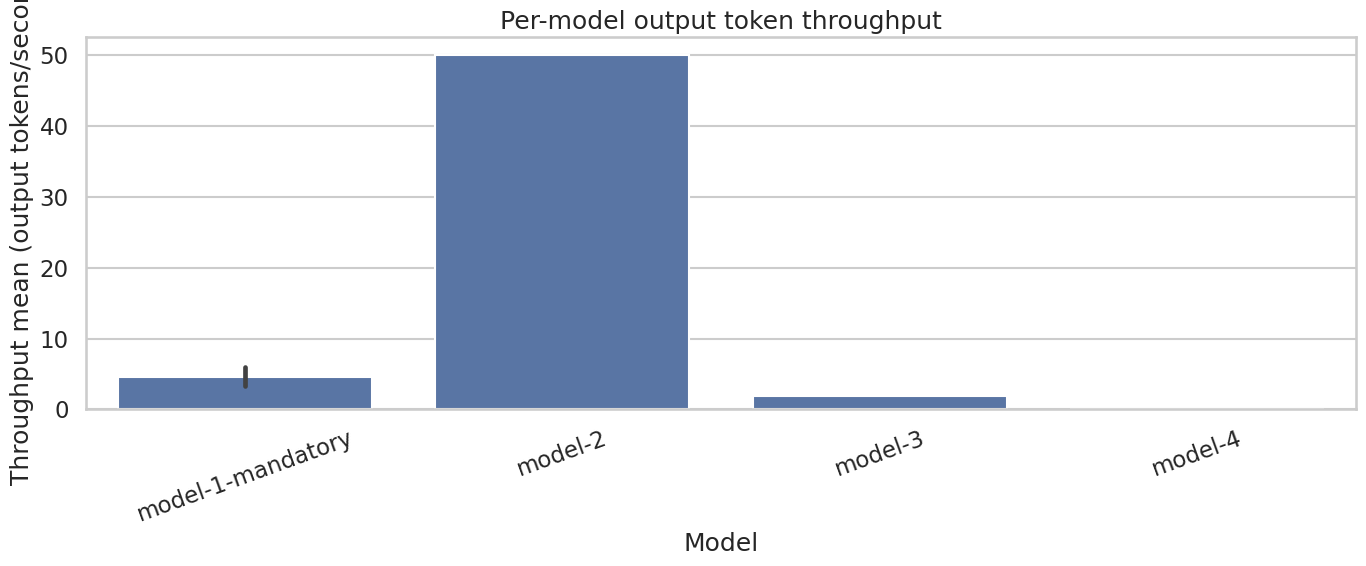

In [7]:
per_model = datasets.get('per_model_metrics')
if per_model is None or len(per_model) == 0:
    display(Markdown('per_model_metrics.csv is missing.'))
else:
    per_model_view = per_model.copy()
    for col in ['ttft_s_mean', 'tpot_s_mean', 'throughput_output_tok_s_mean', 'total_throughput_output_tok_s_mean', 'goodput_sla_fraction_mean', 'max_vmhwm_kb']:
        if col in per_model_view.columns:
            per_model_view[col] = pd.to_numeric(per_model_view[col], errors='coerce')
    per_model_view['TPOT mean (milliseconds/token)'] = per_model_view['tpot_s_mean'] * 1000.0
    per_model_view['Peak memory VmHWM (GiB)'] = per_model_view['max_vmhwm_kb'] / (1024.0 * 1024.0)
    display(per_model_view.rename(columns={
        'model_label': 'Model',
        'configuration_count': 'Configuration count',
        'prompt_count': 'Prompt count',
        'successful_runs': 'Successful measured requests',
        'ttft_s_mean': 'TTFT mean (seconds)',
        'throughput_output_tok_s_mean': 'Throughput mean (output tokens/second)',
        'total_throughput_output_tok_s_mean': 'Total throughput mean (output tokens/second)',
        'goodput_sla_fraction_mean': 'Goodput SLA fraction mean',
    }).sort_values('Model').reset_index(drop=True))

    plt.figure(figsize=(14, 6))
    sns.barplot(data=per_model_view, x='model_label', y='throughput_output_tok_s_mean')
    plt.title('Per-model output token throughput')
    plt.xlabel('Model')
    plt.ylabel('Throughput mean (output tokens/second)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## Model-to-model percentage deltas

This table compares every detected model against the mandatory baseline model (`model-1-mandatory` when present). Positive throughput deltas are better; positive TTFT, TPOT, and memory deltas mean the model is slower or uses more memory than the baseline.


,Model,Baseline model,Configuration count,Prompt count,Successful measured requests,Throughput mean (output tokens/second),Throughput delta vs baseline (%),Total throughput mean (output tokens/second),Total throughput delta vs baseline (%),TTFT mean (seconds),TTFT delta vs baseline (%),TPOT mean (milliseconds/token),TPOT delta vs baseline (%),Peak memory VmHWM (GiB),Peak memory delta vs baseline (%),Goodput SLA fraction mean
0,model-1-mandatory,model-1-mandatory,6,15,90,3.262492,0.000000,293.624290,0.000000,0.965430,0.000000,295.076097,0.000000,4.996704,0.000000,0.022222
1,model-1-mandatory,model-1-mandatory,136,15,2012,6.017574,84.447173,12107.359814,4023.419022,0.817377,-15.335386,241.221561,-18.251067,9.183418,83.789516,0.654412
2,model-2,model-1-mandatory,4,15,60,50.028526,1433.445115,3001.711552,922.296744,0.081707,-91.536752,19.457333,-93.405995,0.567993,-88.632644,1.000000
3,model-3,model-1-mandatory,7,15,105,1.923637,-41.037812,201.981856,-31.210781,3.743005,287.703472,134.560723,-54.397959,7.365170,47.400554,0.190476
4,model-4,model-1-mandatory,7,15,105,0.093382,-97.137696,9.805155,-96.660646,5.795996,500.353977,147.092067,-50.151141,20.965954,319.595665,0.000000


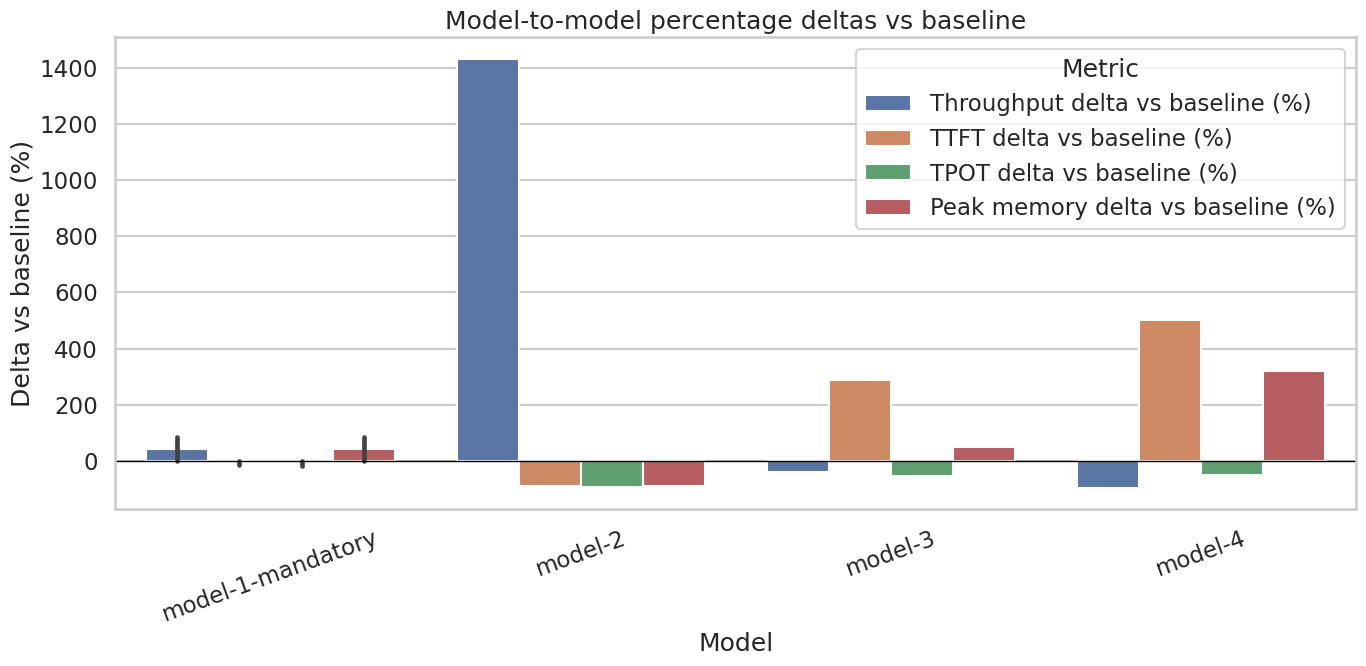

In [8]:
model_deltas = model_delta_table(datasets.get('per_model_metrics'), baseline_label='model-1-mandatory')
datasets['model_delta_metrics'] = model_deltas
if model_deltas is None or len(model_deltas) == 0:
    display(Markdown('Model-to-model percentage deltas are unavailable because per_model_metrics.csv is missing or empty.'))
else:
    display(model_deltas.rename(columns={
        'model_label': 'Model',
        'configuration_count': 'Configuration count',
        'prompt_count': 'Prompt count',
        'successful_runs': 'Successful measured requests',
        'throughput_output_tok_s_mean': 'Throughput mean (output tokens/second)',
        'total_throughput_output_tok_s_mean': 'Total throughput mean (output tokens/second)',
        'ttft_s_mean': 'TTFT mean (seconds)',
        'goodput_sla_fraction_mean': 'Goodput SLA fraction mean',
    }))

    plot_cols = [
        'Throughput delta vs baseline (%)',
        'TTFT delta vs baseline (%)',
        'TPOT delta vs baseline (%)',
        'Peak memory delta vs baseline (%)',
    ]
    plot_df = model_deltas.melt(id_vars=['model_label'], value_vars=plot_cols, var_name='Metric', value_name='Delta percent').dropna()
    if len(plot_df) > 0:
        plt.figure(figsize=(14, 7))
        sns.barplot(data=plot_df, x='model_label', y='Delta percent', hue='Metric')
        plt.axhline(0, color='black', linewidth=1)
        plt.title('Model-to-model percentage deltas vs baseline')
        plt.xlabel('Model')
        plt.ylabel('Delta vs baseline (%)')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()


## Multi-node scalability

This section parses node-count benchmark outputs from `node_scaling_metrics.csv`. The RPC coordinator runs one `llama-server` on rank 0 and attaches ranks 1..N-1 as `rpc-server` workers, so these values measure RPC model-parallel scaling rather than independent replica scaling.


Node-scaling source runs detected from the readable exports.

,source_run,engine,model_label,model,node_counts,prompt_count,successful_runs
0,1258661-track-a1-node-scaling,llamacpp-optimal,model-1-mandatory,/projects/F202500010HPCVLABUMINHO/uminhocp006/...,"1, 2, 4, 6, 8, 16",15,90


,source_run,suite,Node count,Replica count,engine,model_label,threads,ctx_size,parallel_requests,prompt_count,successful_runs,Total throughput mean (output tokens/second),Time to first token mean (seconds),Time per output token mean (milliseconds/token),Goodput SLA fraction mean,Peak memory VmHWM (GiB)
0,model-1-mandatory,node-scaling-n1,1,1,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,55.424531,0.803439,261.135473,0.066667,4.996704
1,model-1-mandatory,node-scaling-n2,2,2,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,49.327496,0.943774,291.051917,0.066667,4.671021
2,model-1-mandatory,node-scaling-n4,4,4,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,48.967468,0.918046,292.149814,0.000000,4.671265
3,model-1-mandatory,node-scaling-n6,6,6,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,46.424746,1.035414,312.078569,0.000000,4.671509
4,model-1-mandatory,node-scaling-n8,8,8,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,46.447834,1.051657,307.844980,0.000000,4.671753
5,model-1-mandatory,node-scaling-n16,16,16,llamacpp-optimal,model-1-mandatory,46,8192,2,15,15,47.032215,1.040248,306.195828,0.000000,4.672607


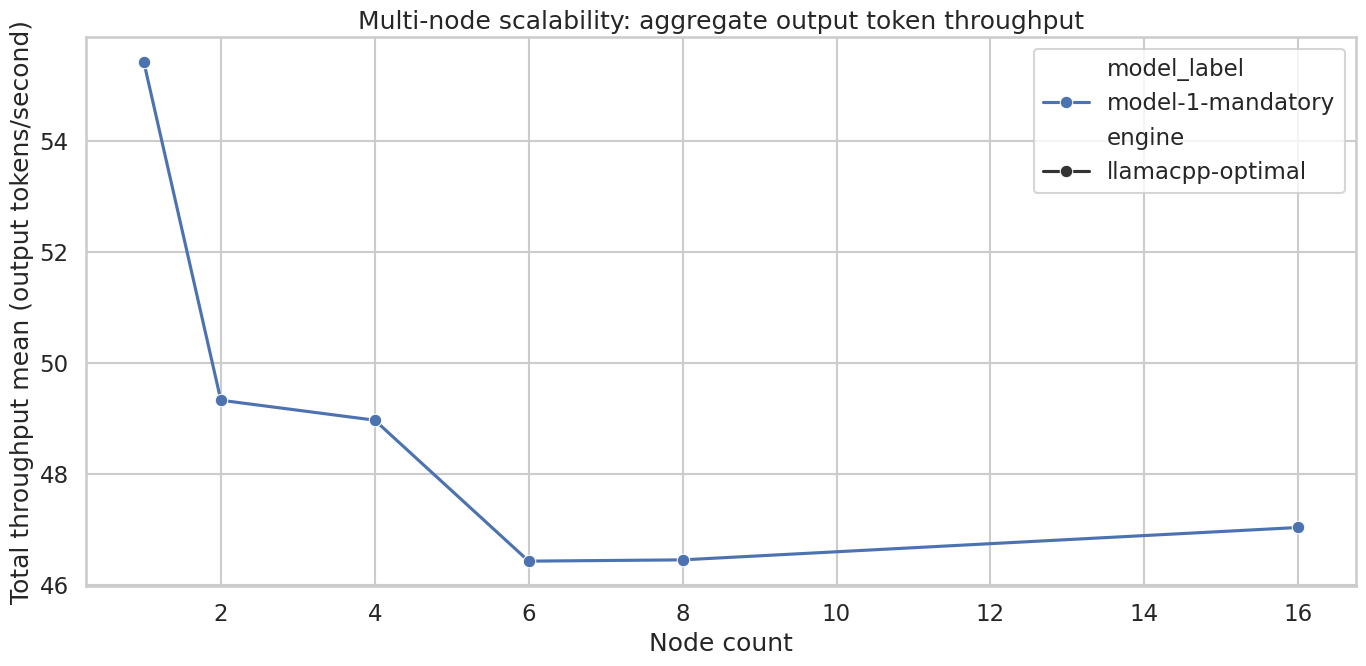

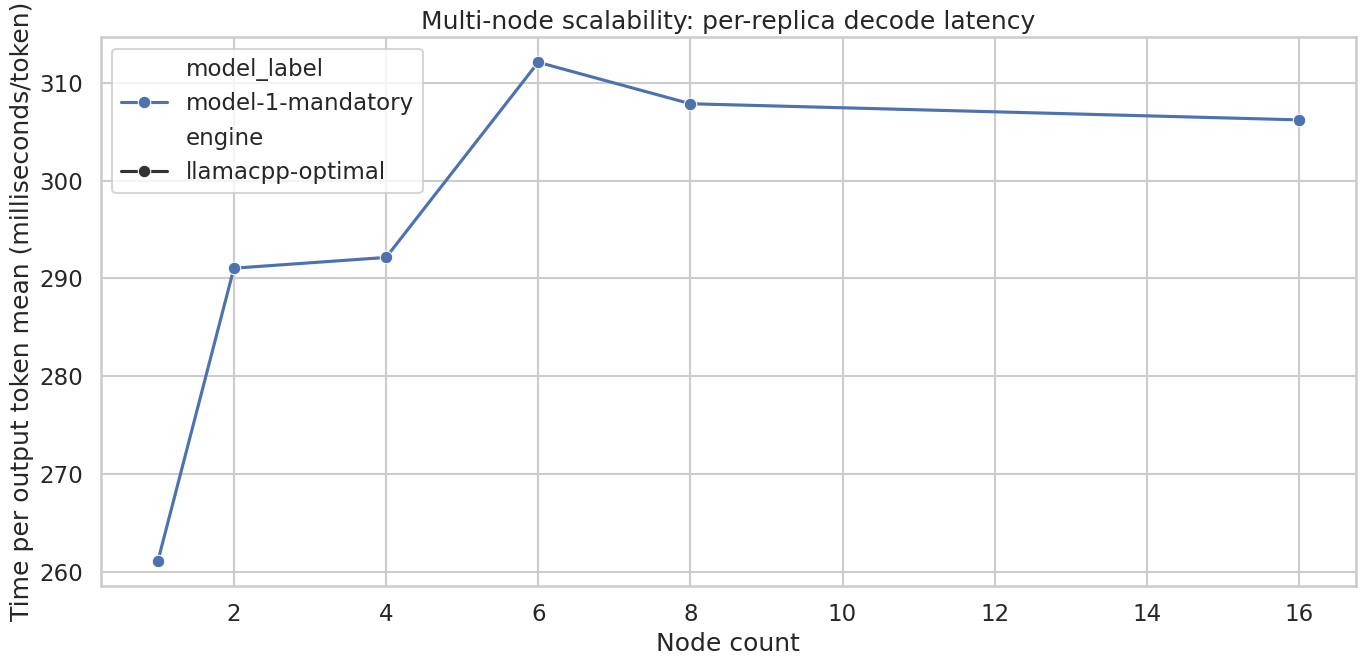

In [9]:
node_scaling = datasets.get('node_scaling_readable')
if node_scaling is None or len(node_scaling) == 0:
    display(Markdown('node_scaling_metrics.csv is missing or has no multi-node benchmark rows.'))
else:
    source_overview = node_scaling_source_overview(node_scaling, datasets.get('all_scaling_rows'))
    if len(source_overview) > 0:
        display(Markdown('Node-scaling source runs detected from the readable exports.'))
        display(source_overview)

    display_cols = [
        'source_run', 'suite', 'Node count', 'Replica count', 'engine', 'model_label', 'threads', 'ctx_size',
        'parallel_requests', 'prompt_count', 'successful_runs',
        'Total throughput mean (output tokens/second)',
        'Time to first token mean (seconds)',
        'Time per output token mean (milliseconds/token)',
        'Goodput SLA fraction mean', 'Peak memory VmHWM (GiB)'
    ]
    display_cols = [col for col in display_cols if col in node_scaling.columns]
    display(node_scaling[display_cols])

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=node_scaling, x='Node count', y='Total throughput mean (output tokens/second)', hue='model_label', style='engine', marker='o')
    plt.title('Multi-node scalability: aggregate output token throughput')
    plt.ylabel('Total throughput mean (output tokens/second)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=node_scaling, x='Node count', y='Time per output token mean (milliseconds/token)', hue='model_label', style='engine', marker='o')
    plt.title('Multi-node scalability: per-replica decode latency')
    plt.ylabel('Time per output token mean (milliseconds/token)')
    plt.tight_layout()
    plt.show()


## Scaling speedup and efficiency

Speedup is aggregate output throughput at each node count divided by the same model's one-node throughput. Efficiency is speedup divided by node count, so 1.0 means ideal linear scaling.


,source_run,engine,model_label,node_count,replica_count,prompt_count,successful_runs,total_throughput_output_tok_s_mean,Throughput speedup vs 1 node,Scaling efficiency vs 1 node,Throughput delta vs 1 node (%),TTFT delta vs 1 node (%),TPOT delta vs 1 node (%),ttft_s_mean_across_replicas,TPOT mean (milliseconds/token),goodput_sla_fraction_mean,Peak memory VmHWM (GiB)
0,model-1-mandatory,llamacpp-optimal,model-1-mandatory,1,1,15,15,55.424531,1.000000,1.000000,0.000000,0.000000,0.000000,0.803439,261.135473,0.066667,4.996704
1,model-1-mandatory,llamacpp-optimal,model-1-mandatory,2,2,15,15,49.327496,0.889994,0.444997,-11.000608,17.466737,11.456293,0.943774,291.051917,0.066667,4.671021
2,model-1-mandatory,llamacpp-optimal,model-1-mandatory,4,4,15,15,48.967468,0.883498,0.220875,-11.650190,14.264487,11.876725,0.918046,292.149814,0.000000,4.671265
3,model-1-mandatory,llamacpp-optimal,model-1-mandatory,6,6,15,15,46.424746,0.837621,0.139603,-16.237910,28.872755,19.508302,1.035414,312.078569,0.000000,4.671509
4,model-1-mandatory,llamacpp-optimal,model-1-mandatory,8,8,15,15,46.447834,0.838037,0.104755,-16.196253,30.894409,17.887078,1.051657,307.844980,0.000000,4.671753
5,model-1-mandatory,llamacpp-optimal,model-1-mandatory,16,16,15,15,47.032215,0.848581,0.053036,-15.141881,29.474301,17.255547,1.040248,306.195828,0.000000,4.672607


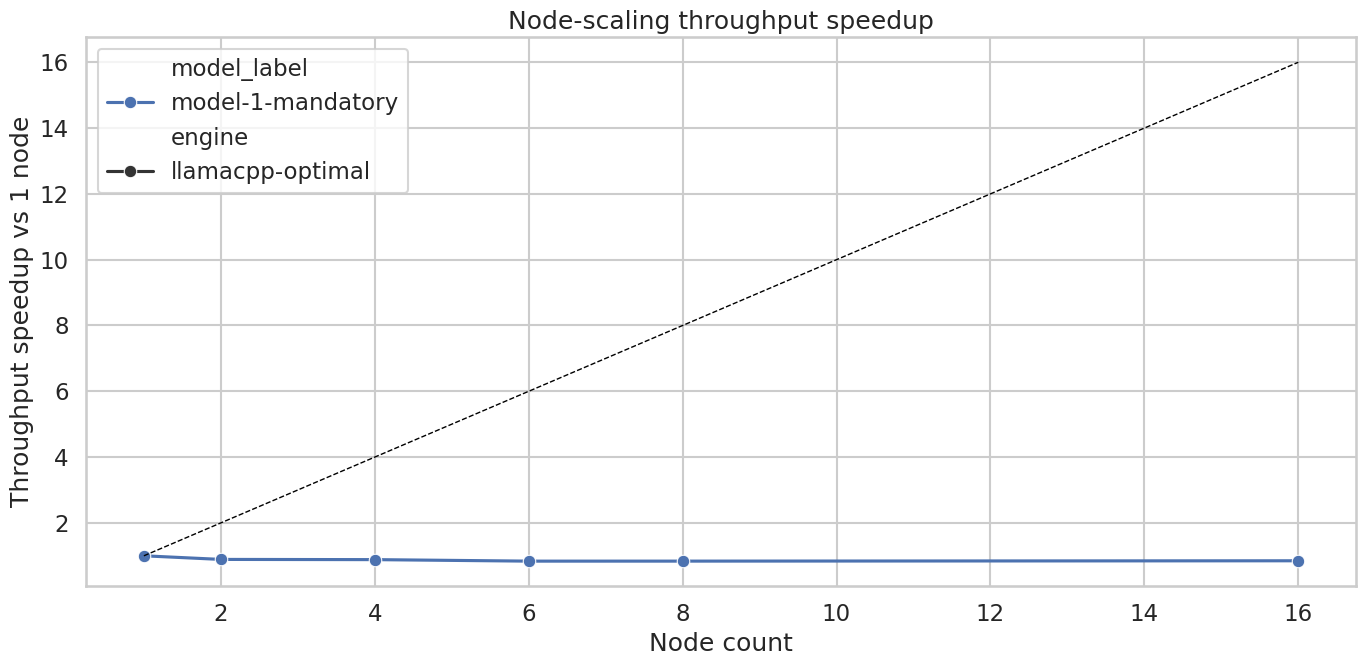

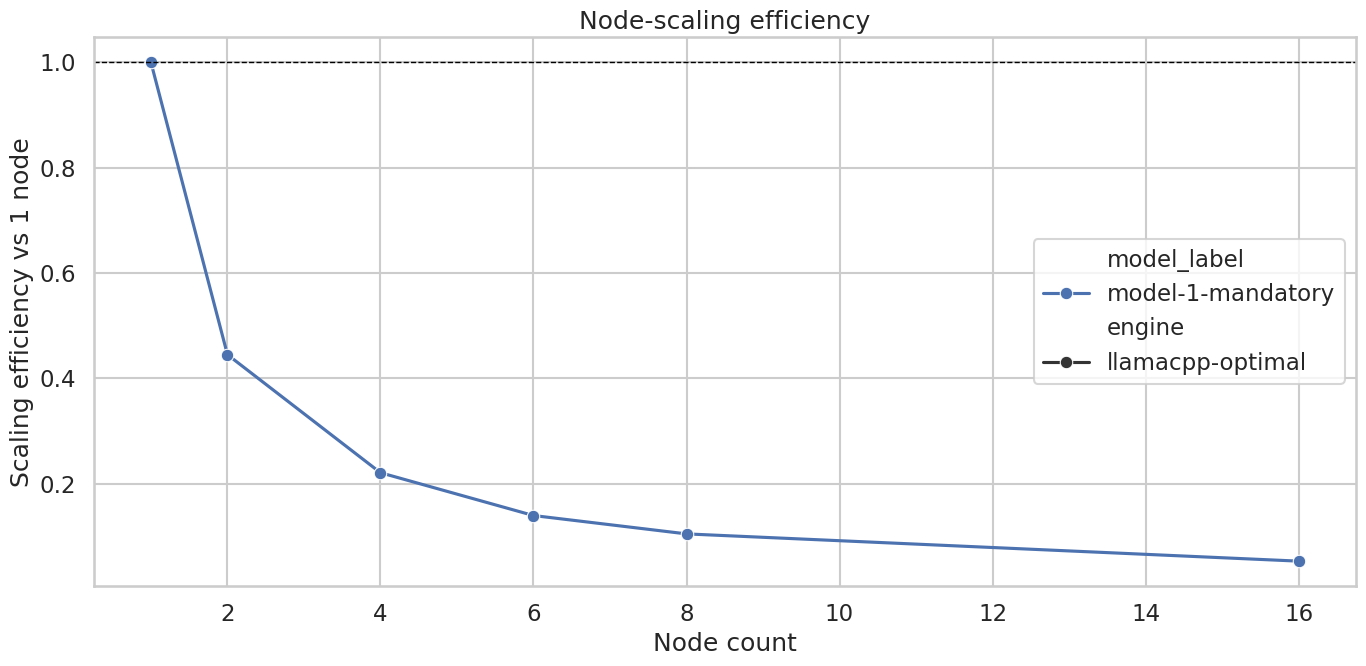

In [10]:
node_scaling_efficiency = node_scaling_efficiency_table(datasets.get('node_scaling_readable'))
datasets['node_scaling_efficiency'] = node_scaling_efficiency
if node_scaling_efficiency is None or len(node_scaling_efficiency) == 0:
    display(Markdown('Scaling speedup and efficiency are unavailable because node_scaling_metrics.csv is missing, empty, or has no usable throughput values.'))
else:
    display_cols = [
        'source_run', 'engine', 'model_label', 'node_count', 'replica_count', 'prompt_count', 'successful_runs',
        'total_throughput_output_tok_s_mean', 'Throughput speedup vs 1 node', 'Scaling efficiency vs 1 node',
        'Throughput delta vs 1 node (%)', 'TTFT delta vs 1 node (%)', 'TPOT delta vs 1 node (%)',
        'ttft_s_mean_across_replicas', 'TPOT mean (milliseconds/token)', 'goodput_sla_fraction_mean', 'Peak memory VmHWM (GiB)'
    ]
    display_cols = [col for col in display_cols if col in node_scaling_efficiency.columns]
    display(node_scaling_efficiency[display_cols])

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=node_scaling_efficiency, x='node_count', y='Throughput speedup vs 1 node', hue='model_label', style='engine', marker='o')
    plt.plot([node_scaling_efficiency['node_count'].min(), node_scaling_efficiency['node_count'].max()], [node_scaling_efficiency['node_count'].min(), node_scaling_efficiency['node_count'].max()], color='black', linewidth=1, linestyle='--', label='Ideal linear')
    plt.title('Node-scaling throughput speedup')
    plt.xlabel('Node count')
    plt.ylabel('Throughput speedup vs 1 node')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=node_scaling_efficiency, x='node_count', y='Scaling efficiency vs 1 node', hue='model_label', style='engine', marker='o')
    plt.axhline(1.0, color='black', linewidth=1, linestyle='--')
    plt.title('Node-scaling efficiency')
    plt.xlabel('Node count')
    plt.ylabel('Scaling efficiency vs 1 node')
    plt.tight_layout()
    plt.show()


## Fixed node-count model comparison

This view ranks all available models at the same node count. By default it uses the largest node count with the highest model coverage, so the four separate model-specific node-scaling runs are compared at a shared node count when possible.


Fixed node-count model comparison at **16 nodes**.

,Node count,Engine,Model,Source run,Prompt count,Successful measured requests,Total throughput mean (output tokens/second),Throughput speedup vs 1 node,Scaling efficiency vs 1 node,TTFT mean across replicas (seconds),TPOT mean (milliseconds/token),Goodput SLA fraction mean,Peak memory VmHWM (GiB)
0,16,llamacpp-optimal,model-1-mandatory,model-1-mandatory,15,15,47.032215,0.848581,0.053036,1.040248,306.195828,0.0,4.672607


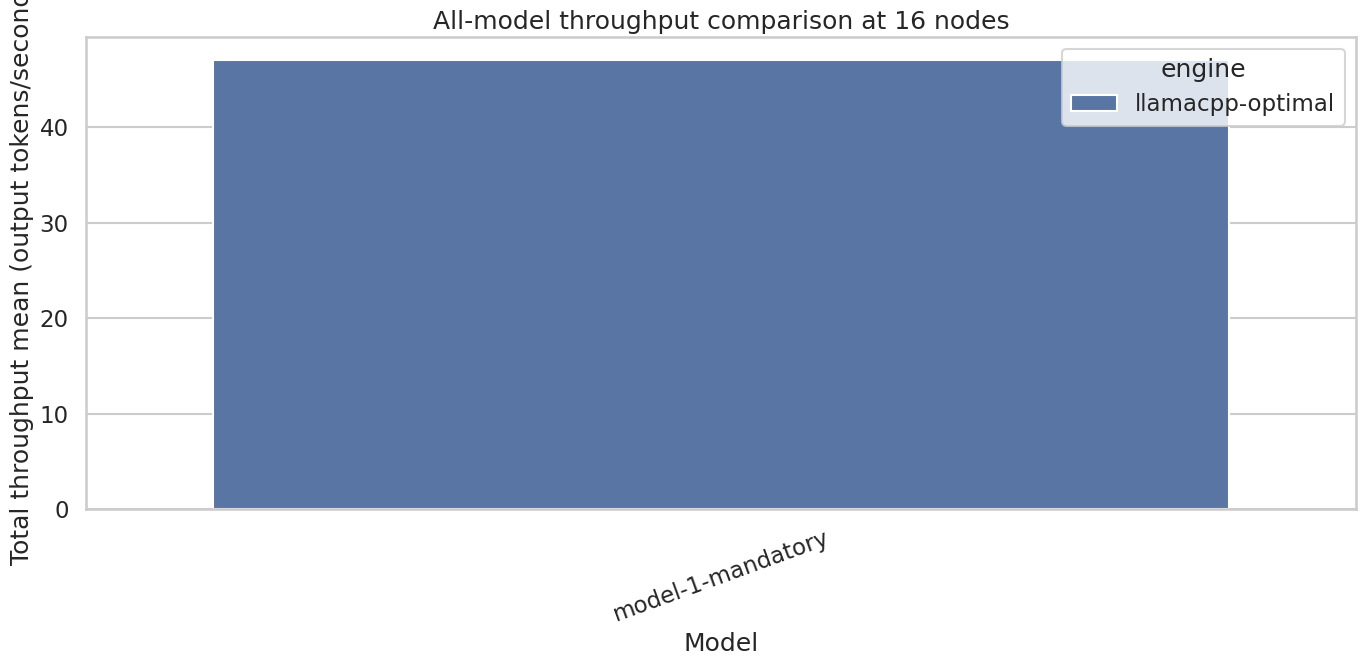

In [11]:
fixed_node_model_comparison, fixed_node_count = fixed_node_model_table(datasets.get('node_scaling_efficiency'))
datasets['fixed_node_model_comparison'] = fixed_node_model_comparison
if fixed_node_model_comparison is None or len(fixed_node_model_comparison) == 0:
    display(Markdown('Fixed node-count model comparison is unavailable because node-scaling efficiency data is missing.'))
else:
    display(Markdown(f'Fixed node-count model comparison at **{fixed_node_count} nodes**.'))
    display(fixed_node_model_comparison.rename(columns={
        'node_count': 'Node count',
        'engine': 'Engine',
        'model_label': 'Model',
        'source_run': 'Source run',
        'prompt_count': 'Prompt count',
        'successful_runs': 'Successful measured requests',
        'total_throughput_output_tok_s_mean': 'Total throughput mean (output tokens/second)',
        'ttft_s_mean_across_replicas': 'TTFT mean across replicas (seconds)',
        'goodput_sla_fraction_mean': 'Goodput SLA fraction mean',
    }))

    plt.figure(figsize=(14, 7))
    sns.barplot(data=fixed_node_model_comparison, x='model_label', y='total_throughput_output_tok_s_mean', hue='engine')
    plt.title(f'All-model throughput comparison at {fixed_node_count} nodes')
    plt.xlabel('Model')
    plt.ylabel('Total throughput mean (output tokens/second)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## Track and assignment requirement checks

This section checks model coverage and mandatory model presence directly from loaded measurements.

In [12]:
prompt_rows = datasets['all_prompt_rows']
if prompt_rows is None:
    raise FileNotFoundError('combined prompt rows file is required for analysis.')

prompt_rows = prompt_rows.copy()
prompt_rows['model_file'] = prompt_rows['model'].astype(str).str.split('/').str[-1]

unique_models = sorted(prompt_rows['model_file'].dropna().unique())
has_mandatory_model = any('Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf' in m for m in unique_models)

summary_checks = pd.DataFrame([
    {'Check': 'Unique model count', 'Value': len(unique_models), 'Requirement': 'At least 3', 'Pass': len(unique_models) >= 3},
    {'Check': 'Mandatory model included', 'Value': has_mandatory_model, 'Requirement': 'Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf present', 'Pass': bool(has_mandatory_model)},
    {'Check': 'Architectures observed', 'Value': ', '.join(sorted(prompt_rows['arch'].dropna().unique())), 'Requirement': 'Architecture comparison should include ARM and x86 when available', 'Pass': True},
    {'Check': 'Engines observed', 'Value': ', '.join(sorted(prompt_rows['engine'].dropna().unique())), 'Requirement': 'Engine variants should be compared', 'Pass': True},
])

display(summary_checks)
display(pd.DataFrame({'Detected model files': unique_models}))

,Check,Value,Requirement,Pass
0,Unique model count,4,At least 3,True
1,Mandatory model included,True,Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf present,True
2,Architectures observed,"arm, x86",Architecture comparison should include ARM and...,True
3,Engines observed,"llamacpp-optimal, tq, vanilla, vanilla-blis, v...",Engine variants should be compared,True


,Detected model files
0,Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf
1,SmolLM2-360M-Instruct.Q4_K_M.gguf
2,gemma-4-E4B-it-OBLITERATED-Q4_K_M.gguf
3,gpt-oss-20b-Q4_K_M.gguf


## Baseline table and metric comparison

Baseline across engines and architectures using full metric names.

,Sweep,Architecture,Engine,Node count,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Decode throughput mean (tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.463455,146.271738,6.495876,6.879761,0.933333,4.831848,15,15,turbo2/turbo2
1,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.475366,155.557095,6.123102,6.492172,0.933333,4.863708,15,15,turbo3/turbo3
2,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.465842,147.400070,6.448116,6.826867,0.933333,4.922180,15,15,turbo4/turbo4
3,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,1.387195,146.092028,2.474017,6.872065,0.333333,5.124207,15,15,turbo2/turbo2
4,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,3.893048,165.826628,2.013969,6.092062,0.200000,5.216492,15,15,turbo3/turbo3
5,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,14.097000,157.770926,0.359572,6.491502,0.066667,5.238892,15,15,turbo4/turbo4
6,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.303982,159.016966,0.077554,6.288637,0.000000,11.121094,15,15,turbo2/turbo2
7,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.385020,161.367551,0.062095,6.197033,0.000000,10.781006,15,15,turbo3/turbo3
8,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.335213,160.179856,0.077149,6.242982,0.000000,11.147522,15,15,turbo4/turbo4
9,1258624-track-a1-server-sweep,arm,vanilla,NaN,model-1-mandatory,24,2048,1,128,0.497065,131.922958,7.166450,7.582787,0.933333,5.419495,15,15,f16/f16


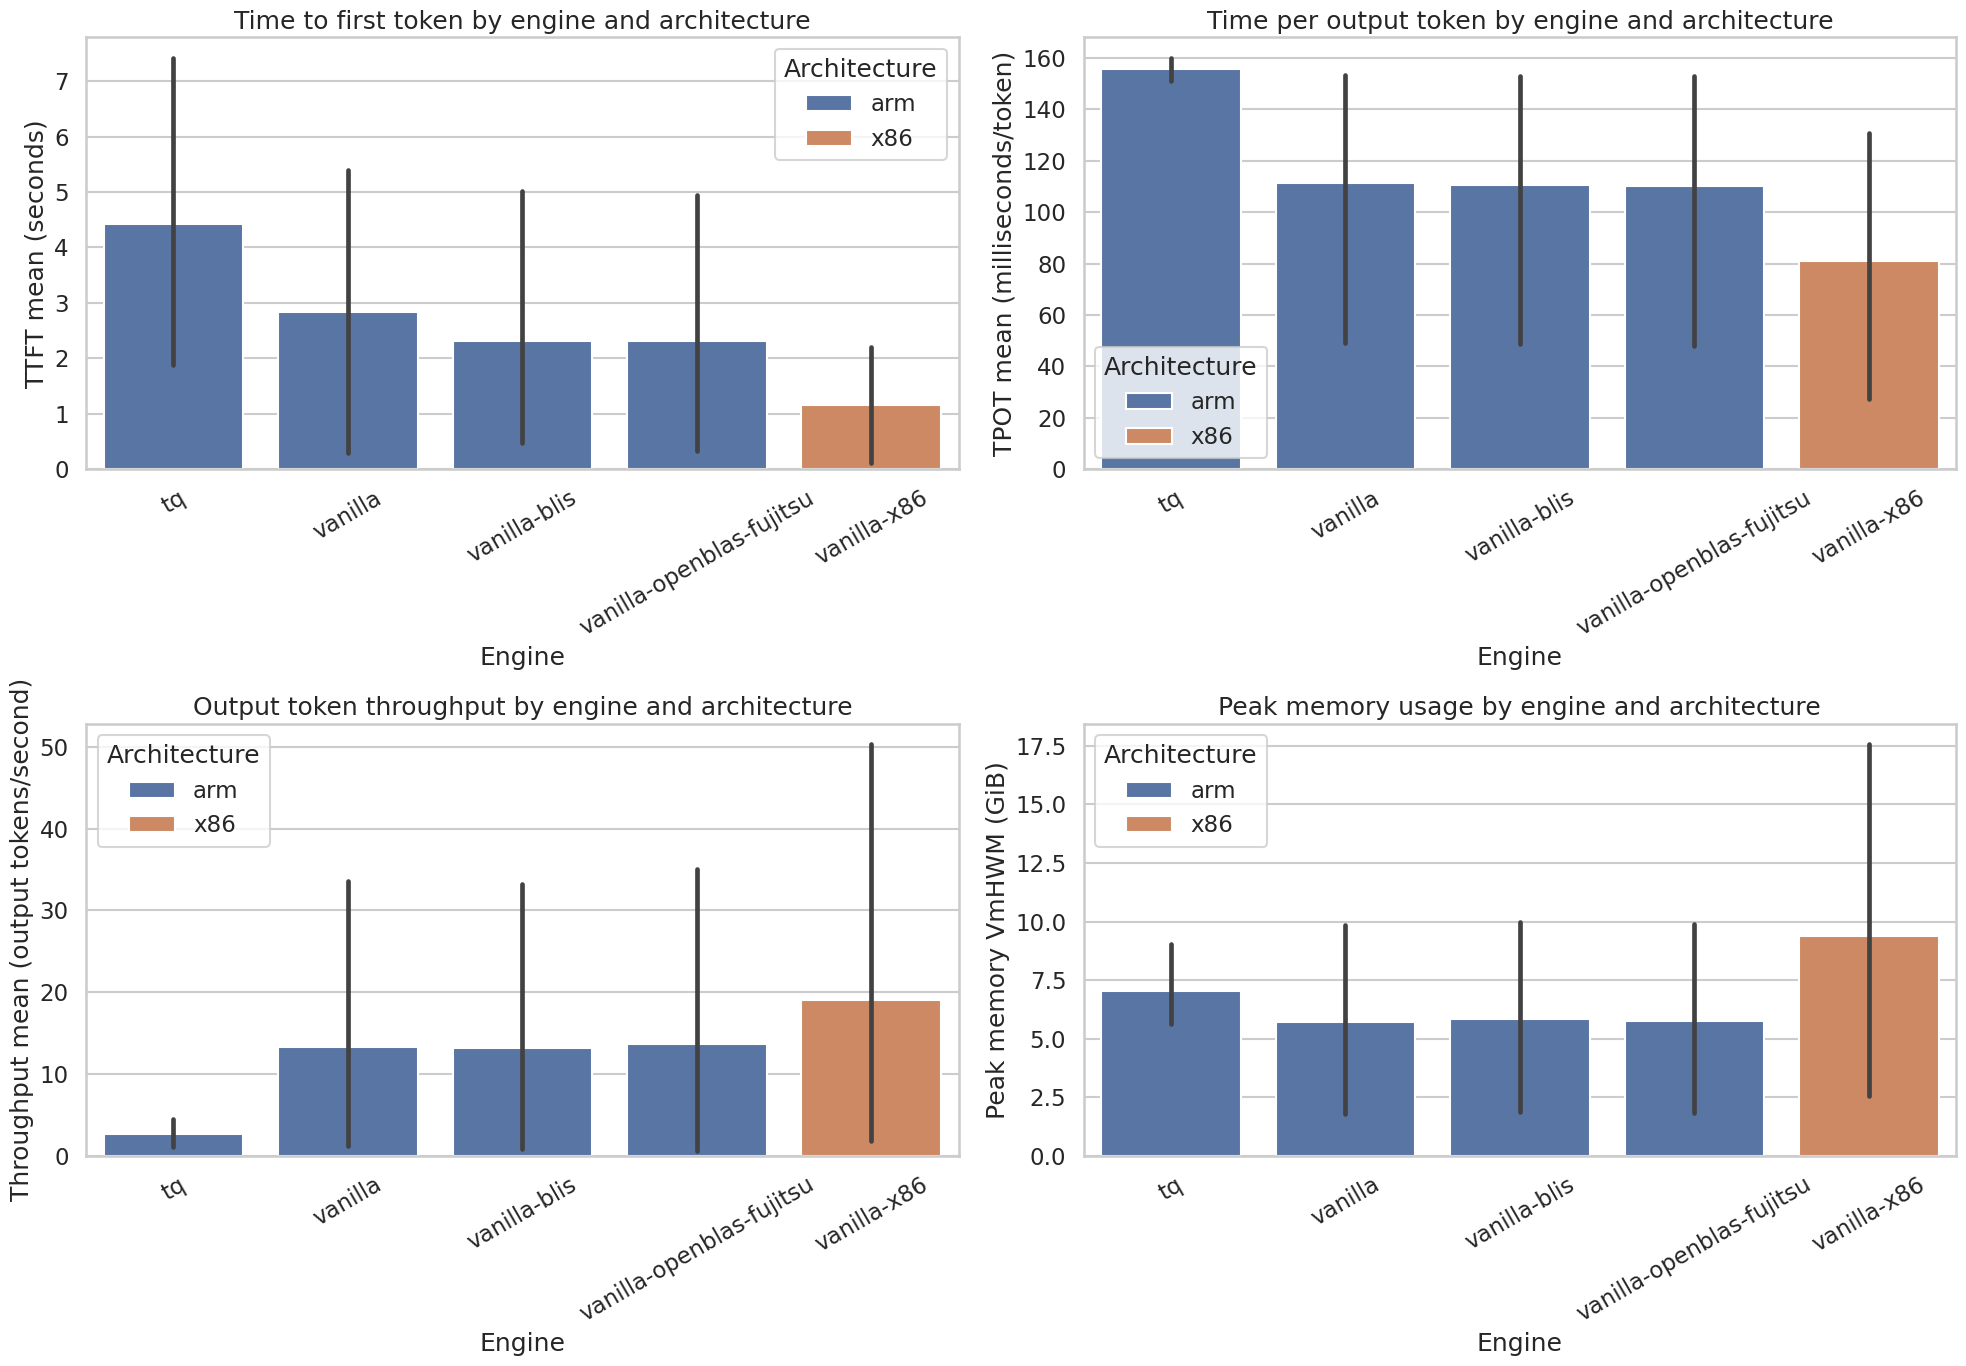

In [13]:
baseline = datasets['baseline_readable']
if baseline is None:
    raise FileNotFoundError('baseline_readable.csv is required for baseline analysis.')

display(baseline.sort_values(['Architecture', 'Engine', 'Model']).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=baseline, x='Engine', y='TTFT mean (seconds)', hue='Architecture', ax=axes[0, 0])
axes[0, 0].set_title('Time to first token by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='TPOT mean (milliseconds/token)', hue='Architecture', ax=axes[0, 1])
axes[0, 1].set_title('Time per output token by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='Throughput mean (output tokens/second)', hue='Architecture', ax=axes[1, 0])
axes[1, 0].set_title('Output token throughput by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='Peak memory VmHWM (GiB)', hue='Architecture', ax=axes[1, 1])
axes[1, 1].set_title('Peak memory usage by engine and architecture')

for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## BLAS comparison (ARM vanilla variants)

Direct comparison of OpenBLAS Fujitsu and BLIS variants.

,Sweep,Architecture,Engine,Node count,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Decode throughput mean (tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1258660-track-a1-vanilla-blas-sweep,arm,vanilla-blis,NaN,model-1-mandatory,24,2048,1,128,0.847359,130.597823,7.147284,7.659864,0.933333,5.702881,15,15,f16/f16
1,1258660-track-a1-vanilla-blas-sweep,arm,vanilla-openblas-fujitsu,NaN,model-1-mandatory,24,2048,1,128,0.535392,131.766045,7.163869,7.591674,0.933333,5.667542,15,15,f16/f16


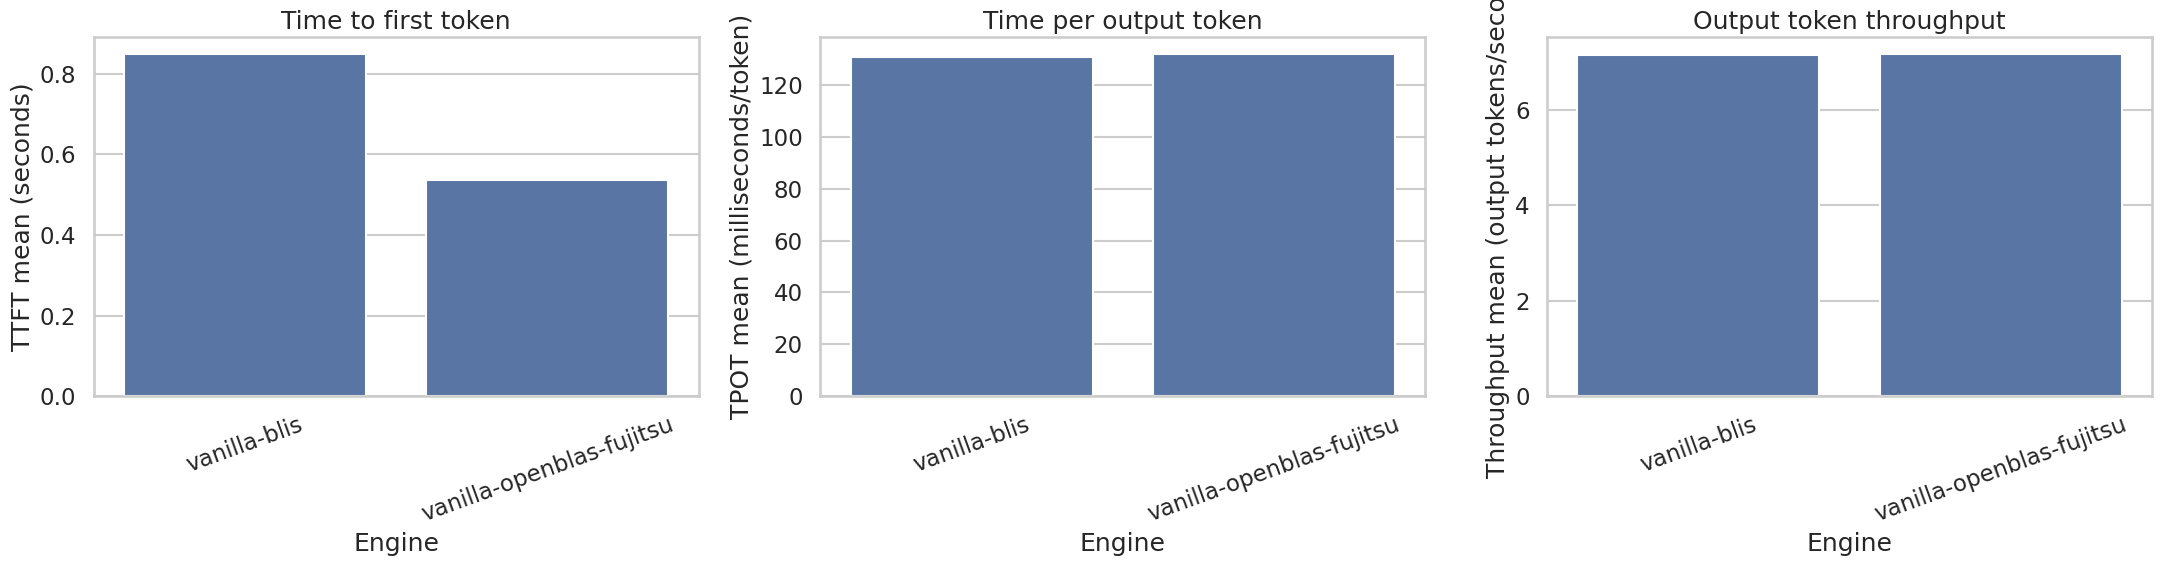

In [14]:
blas = datasets['blas_readable']
if blas is not None and len(blas) > 0:
    display(blas)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.barplot(data=blas, x='Engine', y='TTFT mean (seconds)', ax=axes[0])
    axes[0].set_title('Time to first token')
    sns.barplot(data=blas, x='Engine', y='TPOT mean (milliseconds/token)', ax=axes[1])
    axes[1].set_title('Time per output token')
    sns.barplot(data=blas, x='Engine', y='Throughput mean (output tokens/second)', ax=axes[2])
    axes[2].set_title('Output token throughput')
    for ax in axes:
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('BLAS comparison table was not found.'))

## Architecture comparison (ARM vs x86)

Focused architecture comparison for the mandatory model baseline.

,Sweep,Architecture,Engine,Node count,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Decode throughput mean (tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.463455,146.271738,6.495876,6.879761,0.933333,4.831848,15,15,turbo2/turbo2
1,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.475366,155.557095,6.123102,6.492172,0.933333,4.863708,15,15,turbo3/turbo3
2,1258624-track-a1-server-sweep,arm,tq,NaN,model-1-mandatory,24,2048,1,128,0.465842,147.400070,6.448116,6.826867,0.933333,4.922180,15,15,turbo4/turbo4
3,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,1.387195,146.092028,2.474017,6.872065,0.333333,5.124207,15,15,turbo2/turbo2
4,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,3.893048,165.826628,2.013969,6.092062,0.200000,5.216492,15,15,turbo3/turbo3
5,1258624-track-a1-server-sweep,arm,tq,NaN,model-3,24,2048,1,128,14.097000,157.770926,0.359572,6.491502,0.066667,5.238892,15,15,turbo4/turbo4
6,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.303982,159.016966,0.077554,6.288637,0.000000,11.121094,15,15,turbo2/turbo2
7,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.385020,161.367551,0.062095,6.197033,0.000000,10.781006,15,15,turbo3/turbo3
8,1258624-track-a1-server-sweep,arm,tq,NaN,model-4,24,2048,1,128,6.335213,160.179856,0.077149,6.242982,0.000000,11.147522,15,15,turbo4/turbo4
9,1258624-track-a1-server-sweep,arm,vanilla,NaN,model-1-mandatory,24,2048,1,128,0.497065,131.922958,7.166450,7.582787,0.933333,5.419495,15,15,f16/f16


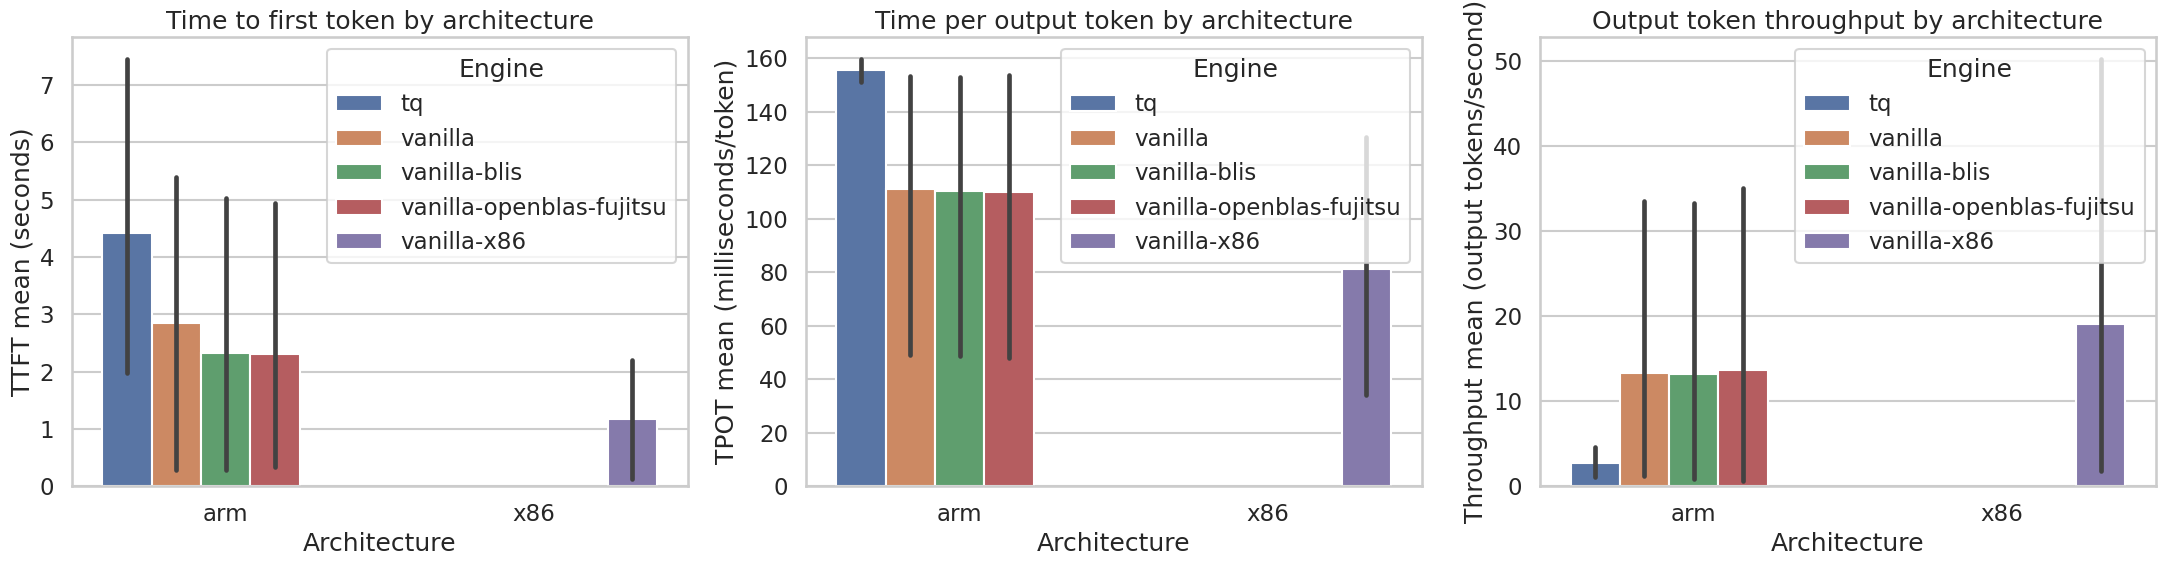

In [15]:
arch_cmp = datasets['architecture_readable']
if arch_cmp is not None and len(arch_cmp) > 0:
    display(arch_cmp)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.barplot(data=arch_cmp, x='Architecture', y='TTFT mean (seconds)', hue='Engine', ax=axes[0])
    axes[0].set_title('Time to first token by architecture')
    sns.barplot(data=arch_cmp, x='Architecture', y='TPOT mean (milliseconds/token)', hue='Engine', ax=axes[1])
    axes[1].set_title('Time per output token by architecture')
    sns.barplot(data=arch_cmp, x='Architecture', y='Throughput mean (output tokens/second)', hue='Engine', ax=axes[2])
    axes[2].set_title('Output token throughput by architecture')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('Architecture comparison table was not found.'))

## Scaling analysis

Trend plots for thread count, request concurrency, context length, and decode length.

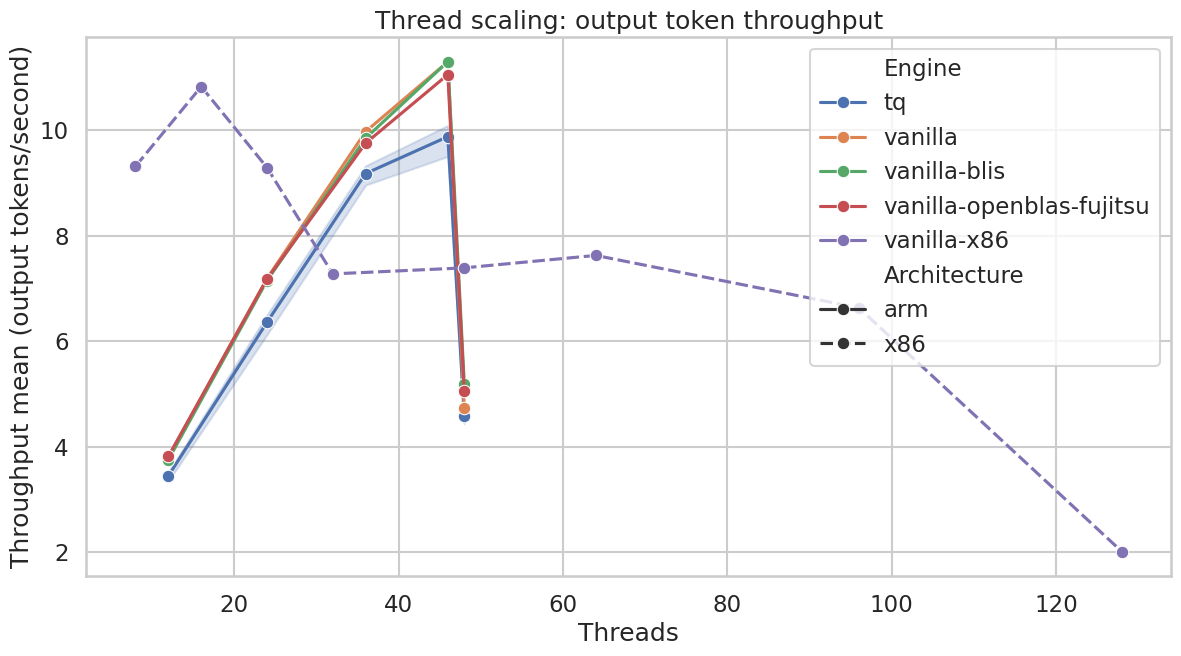

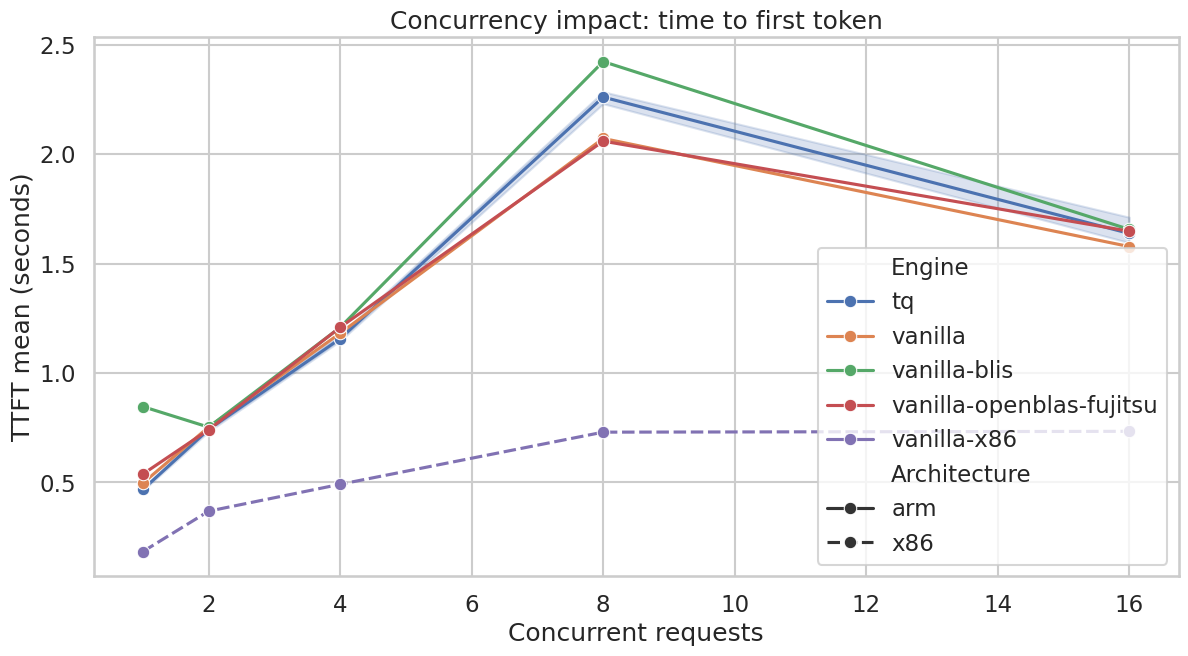

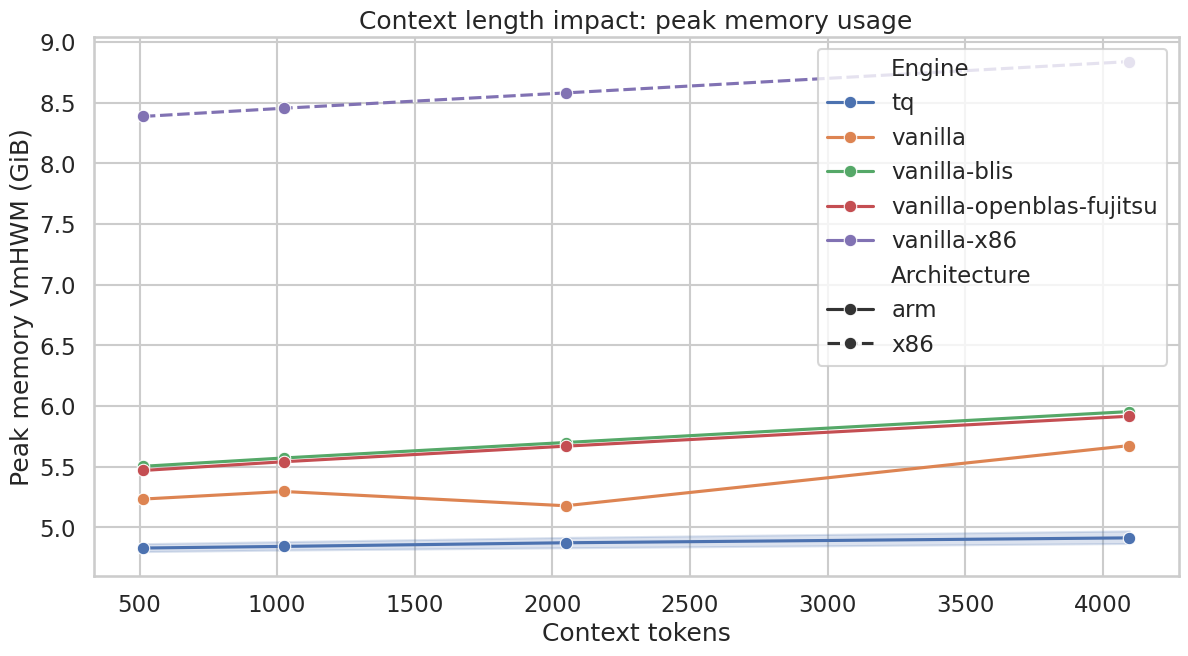

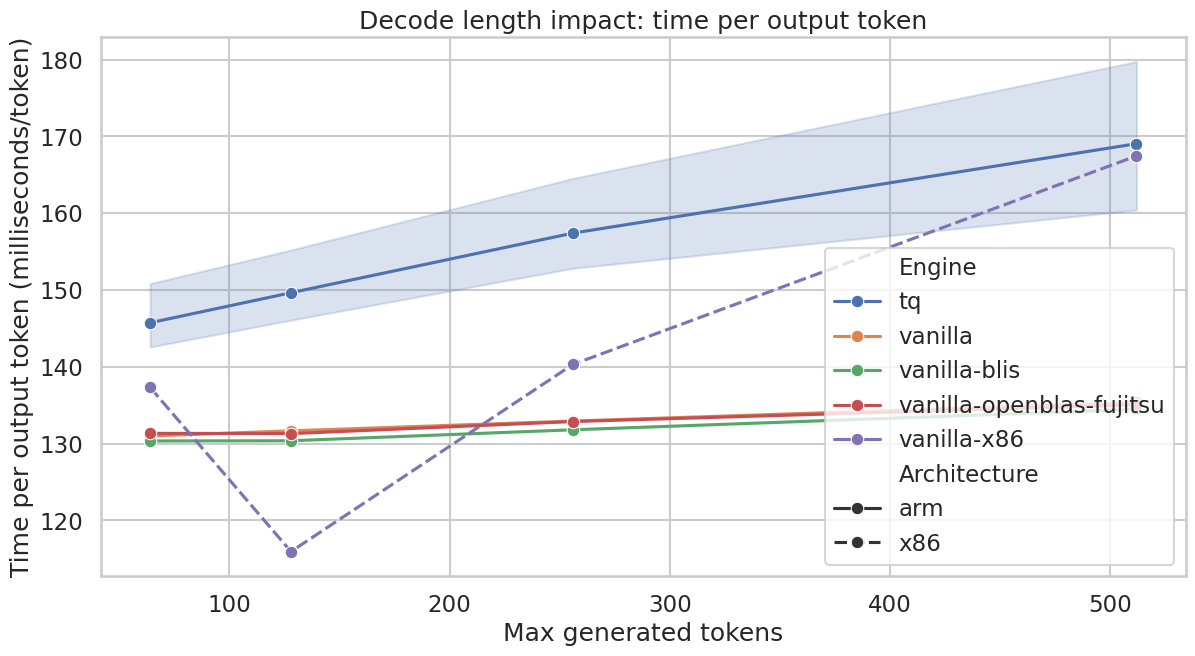

In [16]:
thread_df = datasets['thread_scaling_readable']
conc_df = datasets['concurrency_readable']
ctx_df = datasets['context_length_readable']
dec_df = datasets['decode_length_readable']

if thread_df is not None and len(thread_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=thread_df, x='Threads', y='Throughput mean (output tokens/second)', hue='Engine', style='Architecture', marker='o')
    plt.title('Thread scaling: output token throughput')
    plt.show()

if conc_df is not None and len(conc_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=conc_df, x='Concurrent requests', y='TTFT mean (seconds)', hue='Engine', style='Architecture', marker='o')
    plt.title('Concurrency impact: time to first token')
    plt.show()

if ctx_df is not None and len(ctx_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=ctx_df, x='Context tokens', y='Peak memory VmHWM (GiB)', hue='Engine', style='Architecture', marker='o')
    plt.title('Context length impact: peak memory usage')
    plt.show()

if dec_df is not None and len(dec_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=dec_df, x='Max generated tokens', y='TPOT mean (milliseconds/token)', hue='Engine', style='Architecture', marker='o')
    plt.title('Decode length impact: time per output token')
    plt.ylabel('Time per output token (milliseconds/token)')
    plt.show()

## Mandatory prompts: outputs, quality, and latency metrics

This section ties generated output quality to measured latency metrics for the three required prompts.

In [17]:
quality = datasets['mandatory_quality']
if quality is None:
    display(Markdown('mandatory_quality.csv is missing.'))
else:
    mandatory_prompt_rows = prompt_rows[prompt_rows['prompt_id'].astype(str).str.startswith('mandatory_')].copy()
    metric_cols = ['run_dir', 'prompt_id', 'category', 'ttft_s_mean', 'tpot_s_mean', 'throughput_output_tok_s_mean', 'goodput_sla_fraction', 'max_vmhwm_kb']
    metric_cols = [c for c in metric_cols if c in mandatory_prompt_rows.columns]
    mandatory_metrics = mandatory_prompt_rows[metric_cols].drop_duplicates()

    merged = quality.merge(mandatory_metrics, how='left', on=['run_dir', 'prompt_id', 'category'])
    merged['time_to_first_token_seconds'] = merged['ttft_s_mean']
    merged['time_per_output_token_milliseconds'] = merged['tpot_s_mean'] * 1000.0
    merged['output_token_throughput_tokens_per_second'] = merged['throughput_output_tok_s_mean']
    merged['peak_memory_gib'] = merged['max_vmhwm_kb'] / (1024.0 * 1024.0)

    quality_summary = (
        merged.groupby(['prompt_id', 'quality_label'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values(['prompt_id', 'count'], ascending=[True, False])
    )
    display(quality_summary)

    display_columns = [
        'prompt_id', 'quality_label', 'quality_notes',
        'time_to_first_token_seconds', 'time_per_output_token_milliseconds',
        'output_token_throughput_tokens_per_second', 'peak_memory_gib', 'generated_text'
    ]
    display_columns = [c for c in display_columns if c in merged.columns]

    representative = (
        merged.sort_values(['prompt_id', 'trial'])
        .groupby('prompt_id', as_index=False)
        .first()[display_columns]
    )
    display(representative)

mandatory_quality.csv is missing.

## Readable prompt-answer CSVs

The generated answers are loaded from `measurements/readable/prompt_answers.csv` and split into mandatory-answer, summary, prompt-catalog, and error tables for notebook inspection. Text newlines are escaped as `\n` so each CSV row remains one readable record.


In [18]:
answer_files = pd.DataFrame([
    {'Dataset': name, 'CSV path': str(path.relative_to(ROOT)), 'Rows': None if datasets.get(name) is None else len(datasets[name])}
    for name, path in paths.items()
    if name in {'prompt_answers', 'mandatory_prompt_answers', 'answer_summary', 'request_errors', 'prompt_catalog', 'all_request_metrics'}
])
display(answer_files)

answers = datasets['prompt_answers']
mandatory_answers = datasets['mandatory_prompt_answers']
answer_summary = datasets['answer_summary']
request_errors = datasets['request_errors']

if mandatory_answers is not None and len(mandatory_answers) > 0:
    preview_cols = [
        'suite', 'engine', 'model_label', 'threads', 'ctx_size', 'parallel_requests',
        'cache_type_k', 'cache_type_v', 'prompt_id', 'trial', 'status', 'error',
        'ttft_s', 'tpot_s', 'throughput_output_tok_s', 'generated_text'
    ]
    preview_cols = [c for c in preview_cols if c in mandatory_answers.columns]
    display(Markdown('### Mandatory prompt answer preview'))
    display(mandatory_answers[preview_cols].head(30))

if answer_summary is not None and len(answer_summary) > 0:
    summary_cols = [
        'suite', 'engine', 'model_label', 'threads', 'ctx_size', 'parallel_requests',
        'cache_type_k', 'cache_type_v', 'prompt_id', 'runs', 'successful_runs',
        'error_runs', 'first_success_answer'
    ]
    summary_cols = [c for c in summary_cols if c in answer_summary.columns]
    display(Markdown('### Compact answer summary'))
    display(answer_summary[summary_cols].head(30))

if request_errors is not None and len(request_errors) > 0:
    error_counts = (
        request_errors.groupby(['suite', 'engine', 'model_label', 'prompt_id', 'error'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    display(Markdown('### Request error counts'))
    display(error_counts.head(30))


,Dataset,CSV path,Rows
0,all_request_metrics,measurements/readable/all_request_metrics.csv,2400
1,prompt_answers,measurements/readable/prompt_answers.csv,2400
2,mandatory_prompt_answers,measurements/readable/mandatory_prompt_answers...,480
3,answer_summary,measurements/readable/answer_summary.csv,2400
4,request_errors,measurements/readable/request_errors.csv,28
5,prompt_catalog,measurements/readable/prompt_catalog.csv,31


### Mandatory prompt answer preview

,suite,engine,model_label,threads,ctx_size,parallel_requests,cache_type_k,cache_type_v,prompt_id,trial,status,error,ttft_s,tpot_s,throughput_output_tok_s,generated_text
0,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_short_capital_france,1,200,NaN,1.612544,1.550556,0.566069,The capital of France is Paris.
1,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_long_transformer_cpu,1,200,NaN,1.601068,1.283047,0.776984,"Based on the context, the main challenges when..."
2,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_medium_ml_vs_dl,1,200,NaN,1.604855,1.240776,0.804083,"Machine learning, deep learning, and artificia..."
3,concurrency,tq,model-1-mandatory,24,2048,16,turbo3,turbo3,mandatory_short_capital_france,1,200,NaN,0.156687,1.656778,0.604287,The capital of France is Paris.
4,concurrency,tq,model-1-mandatory,24,2048,16,turbo3,turbo3,mandatory_long_transformer_cpu,1,200,NaN,1.835649,1.328992,0.748877,"Based on the context provided, the main challe..."
5,concurrency,tq,model-1-mandatory,24,2048,16,turbo3,turbo3,mandatory_medium_ml_vs_dl,1,200,NaN,1.840577,1.281744,0.777533,**Machine Learning (ML) vs Deep Learning (DL)*...
6,concurrency,tq,model-1-mandatory,24,2048,16,turbo4,turbo4,mandatory_short_capital_france,1,200,NaN,1.604224,1.533355,0.571079,The capital of France is Paris.
7,concurrency,tq,model-1-mandatory,24,2048,16,turbo4,turbo4,mandatory_long_transformer_cpu,1,200,NaN,1.589302,1.304350,0.764574,"Based on the context provided, the main challe..."
8,concurrency,tq,model-1-mandatory,24,2048,16,turbo4,turbo4,mandatory_medium_ml_vs_dl,1,200,NaN,1.591006,1.265675,0.788506,Machine learning and deep learning are both su...
9,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,mandatory_short_capital_france,1,200,NaN,1.236117,0.128854,3.272939,The capital of France is Paris.


### Compact answer summary

,suite,engine,model_label,threads,ctx_size,parallel_requests,cache_type_k,cache_type_v,prompt_id,runs,successful_runs,error_runs,first_success_answer
0,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,long_concurrency_server,1,1,0,Designing and Interpreting a Concurrency Bench...
1,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,long_hpc_case_study,1,0,1,NaN
2,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,long_memory_bound_reasoning,1,0,1,NaN
3,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,long_quantisation_evaluation,1,1,0,**Evaluation Plan: Quantization
4,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_long_transformer_cpu,1,1,0,"Based on the context, the main challenges when..."
5,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_medium_ml_vs_dl,1,1,0,"Machine learning, deep learning, and artificia..."
6,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_short_capital_france,1,1,0,The capital of France is Paris.
7,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,medium_concurrency,1,1,0,When benchmarking an LLM (Large Language Model...
8,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,medium_cpu_inference_pipeline,1,1,0,The main stages of the pipeline are:\n\n1. **T...
9,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,medium_quant_tradeoff,1,1,0,The model is available in various quantization...


### Request error counts

,suite,engine,model_label,prompt_id,error,count
0,concurrency,tq,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,6
1,concurrency,tq,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,6
2,concurrency,vanilla,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,2
3,concurrency,vanilla,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,2
4,concurrency,vanilla-blis,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,2
5,concurrency,vanilla-blis,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,2
6,concurrency,vanilla-openblas-fujitsu,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,2
7,concurrency,vanilla-openblas-fujitsu,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,2
8,concurrency,vanilla-x86,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,2
9,concurrency,vanilla-x86,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,2


## Trial stability (mean and standard deviation)

Three-trial stability view using available per-prompt standard deviation values.

In [19]:
stability_cols = [
    'engine', 'arch', 'model_label', 'prompt_id', 'ttft_s_mean', 'ttft_s_stdev',
    'tpot_s_mean', 'tpot_s_stdev', 'throughput_output_tok_s_mean', 'throughput_output_tok_s_stdev'
]
stability_cols = [c for c in stability_cols if c in prompt_rows.columns]
stability = prompt_rows[stability_cols].copy()
stability['ttft_relative_std_percent'] = 100.0 * (stability['ttft_s_stdev'] / stability['ttft_s_mean'].replace(0, np.nan))
stability['time_per_output_token_relative_std_percent'] = 100.0 * (stability['tpot_s_stdev'] / stability['tpot_s_mean'].replace(0, np.nan))
stability['throughput_relative_std_percent'] = 100.0 * (stability['throughput_output_tok_s_stdev'] / stability['throughput_output_tok_s_mean'].replace(0, np.nan))

display(
    stability[
        ['engine', 'arch', 'model_label', 'prompt_id',
         'ttft_relative_std_percent',
         'time_per_output_token_relative_std_percent',
         'throughput_relative_std_percent']
    ]
    .sort_values('throughput_relative_std_percent', ascending=False)
    .head(20)
)

,engine,arch,model_label,prompt_id,ttft_relative_std_percent,time_per_output_token_relative_std_percent,throughput_relative_std_percent
0,tq,arm,model-1-mandatory,long_concurrency_server,0.0,0.0,0.0
3,tq,arm,model-1-mandatory,long_quantisation_evaluation,0.0,0.0,0.0
4,tq,arm,model-1-mandatory,mandatory_long_transformer_cpu,0.0,0.0,0.0
5,tq,arm,model-1-mandatory,mandatory_medium_ml_vs_dl,0.0,0.0,0.0
6,tq,arm,model-1-mandatory,medium_concurrency,0.0,0.0,0.0
7,tq,arm,model-1-mandatory,medium_cpu_inference_pipeline,0.0,0.0,0.0
8,tq,arm,model-1-mandatory,medium_quant_tradeoff,0.0,0.0,0.0
9,tq,arm,model-1-mandatory,medium_thread_scaling,0.0,0.0,0.0
10,tq,arm,model-1-mandatory,mandatory_short_capital_france,0.0,0.0,0.0
11,tq,arm,model-1-mandatory,short_batching,0.0,0.0,0.0


## Performance model validation: predicted vs observed time per output token

Uses the generated model table (`performance_model.csv`) and visualizes where the simple model is accurate or deviates.

In [20]:
perf = datasets['performance_model']
if perf is None or len(perf) == 0:
    display(Markdown('performance_model.csv was not found.'))
else:
    perf = perf.copy()
    perf['predicted_time_per_output_token_milliseconds'] = perf['tpot_pred_s'] * 1000.0
    perf['observed_time_per_output_token_milliseconds'] = perf['tpot_observed_s'] * 1000.0
    perf['prediction_error_percent'] = 100.0 * (perf['tpot_observed_s'] - perf['tpot_pred_s']) / perf['tpot_pred_s'].replace(0, np.nan)
    display(perf[['sweep_id', 'arch', 'engine', 'model_label', 'cache_type_k', 'calibrated_bw_gb_s', 'predicted_time_per_output_token_milliseconds', 'observed_time_per_output_token_milliseconds', 'prediction_error_percent']])

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=perf,
        x='predicted_time_per_output_token_milliseconds',
        y='observed_time_per_output_token_milliseconds',
        hue='engine',
        style='arch',
        s=120
    )
    max_val = float(max(perf['predicted_time_per_output_token_milliseconds'].max(), perf['observed_time_per_output_token_milliseconds'].max()))
    plt.plot([0, max_val], [0, max_val], linestyle='--', color='black', label='perfect prediction')
    plt.title('Predicted versus observed time per output token')
    plt.xlabel('Predicted time per output token (milliseconds/token)')
    plt.ylabel('Observed time per output token (milliseconds/token)')
    plt.legend()
    plt.tight_layout()
    plt.show()

performance_model.csv was not found.

## Metric availability note

If prompt token throughput is not present in raw files, the notebook still analyzes all available mandatory metrics and decode throughput.

In [21]:
possible_prefill_cols = [
    'throughput_prompt_tok_s_mean',
    'prefill_throughput_tok_s_mean',
    'prompt_throughput_tok_s_mean'
]
present_prefill_cols = [c for c in possible_prefill_cols if c in prompt_rows.columns]

if present_prefill_cols:
    display(Markdown(f'Prompt-token throughput columns detected: `{present_prefill_cols}`'))
    display(prompt_rows[present_prefill_cols].describe(include='all'))
else:
    display(Markdown('Prompt-token throughput is not present in the currently available CSV schema. Decode/output token throughput is fully analyzed.'))

Prompt-token throughput is not present in the currently available CSV schema. Decode/output token throughput is fully analyzed.

## Vanilla vs TurboQuant direct deltas (latency, tokens, memory)

Direct side-by-side comparison for matching architecture+model baseline rows.


In [22]:
baseline = datasets['baseline_readable']
cmp_cols = ['Architecture','Model','Engine','KV cache K/V','TTFT mean (seconds)','TPOT mean (milliseconds/token)','Throughput mean (output tokens/second)','Peak memory VmHWM (GiB)']
b = baseline[cmp_cols].copy()
for col in ['TTFT mean (seconds)','TPOT mean (milliseconds/token)','Throughput mean (output tokens/second)','Peak memory VmHWM (GiB)']:
    b[col] = pd.to_numeric(b[col], errors='coerce')
vanilla = b[b['Engine']=='vanilla'].copy()
tq = b[b['Engine']=='tq'].copy()
if vanilla.empty or tq.empty:
    display(Markdown('Could not find both `vanilla` and `tq` rows in baseline table.'))
else:
    vanilla = vanilla.rename(columns={'TTFT mean (seconds)':'TTFT vanilla (s)','TPOT mean (milliseconds/token)':'TPOT vanilla (ms/token)','Throughput mean (output tokens/second)':'Throughput vanilla (tok/s)','Peak memory VmHWM (GiB)':'Memory vanilla (GiB)'})
    tq = tq.rename(columns={'KV cache K/V':'TQ KV cache','TTFT mean (seconds)':'TTFT tq (s)','TPOT mean (milliseconds/token)':'TPOT tq (ms/token)','Throughput mean (output tokens/second)':'Throughput tq (tok/s)','Peak memory VmHWM (GiB)':'Memory tq (GiB)'})
    merged = tq.merge(vanilla[['Architecture','Model','TTFT vanilla (s)','TPOT vanilla (ms/token)','Throughput vanilla (tok/s)','Memory vanilla (GiB)']], on=['Architecture','Model'], how='inner')
    merged['TTFT delta % (tq-vs-vanilla)'] = 100.0 * (merged['TTFT tq (s)'] - merged['TTFT vanilla (s)']) / merged['TTFT vanilla (s)']
    merged['TPOT delta % (tq-vs-vanilla)'] = 100.0 * (merged['TPOT tq (ms/token)'] - merged['TPOT vanilla (ms/token)']) / merged['TPOT vanilla (ms/token)']
    merged['Throughput delta % (tq-vs-vanilla)'] = 100.0 * (merged['Throughput tq (tok/s)'] - merged['Throughput vanilla (tok/s)']) / merged['Throughput vanilla (tok/s)']
    merged['Memory delta % (tq-vs-vanilla)'] = 100.0 * (merged['Memory tq (GiB)'] - merged['Memory vanilla (GiB)']) / merged['Memory vanilla (GiB)']
    display(merged.sort_values(['Architecture','Model','TQ KV cache']).reset_index(drop=True))


,Architecture,Model,Engine,TQ KV cache,TTFT tq (s),TPOT tq (ms/token),Throughput tq (tok/s),Memory tq (GiB),TTFT vanilla (s),TPOT vanilla (ms/token),Throughput vanilla (tok/s),Memory vanilla (GiB),TTFT delta % (tq-vs-vanilla),TPOT delta % (tq-vs-vanilla),Throughput delta % (tq-vs-vanilla),Memory delta % (tq-vs-vanilla)
0,arm,model-1-mandatory,tq,turbo2/turbo2,0.463455,146.271738,6.495876,4.831848,0.497065,131.922958,7.166450,5.419495,-6.761658,10.876636,-9.357130,-10.843197
1,arm,model-1-mandatory,tq,turbo3/turbo3,0.475366,155.557095,6.123102,4.863708,0.497065,131.922958,7.166450,5.419495,-4.365438,17.915105,-14.558784,-10.255313
2,arm,model-1-mandatory,tq,turbo4/turbo4,0.465842,147.400070,6.448116,4.922180,0.497065,131.922958,7.166450,5.419495,-6.281468,11.731932,-10.023575,-9.176399
3,arm,model-3,tq,turbo2/turbo2,1.387195,146.092028,2.474017,5.124207,4.368392,130.398689,2.196896,5.508850,-68.244718,12.034890,12.614224,-6.982284
4,arm,model-3,tq,turbo3/turbo3,3.893048,165.826628,2.013969,5.216492,4.368392,130.398689,2.196896,5.508850,-10.881449,27.168938,-8.326585,-5.307068
5,arm,model-3,tq,turbo4/turbo4,14.097000,157.770926,0.359572,5.238892,4.368392,130.398689,2.196896,5.508850,222.704553,20.991191,-83.632723,-4.900451
6,arm,model-4,tq,turbo2/turbo2,6.303982,159.016966,0.077554,11.121094,6.418604,161.206409,0.076241,11.330200,-1.785774,-1.358161,1.722131,-1.845567
7,arm,model-4,tq,turbo3/turbo3,6.385020,161.367551,0.062095,10.781006,6.418604,161.206409,0.076241,11.330200,-0.523228,0.099960,-18.554228,-4.847172
8,arm,model-4,tq,turbo4/turbo4,6.335213,160.179856,0.077149,11.147522,6.418604,161.206409,0.076241,11.330200,-1.299210,-0.636794,1.190950,-1.612312


## Strict assignment compliance check (dataset and measured runs)

Separates "available in dataset" from "actually measured in runs".


In [23]:
import json
from collections import Counter
req_rows = []
prompts_path = ROOT / 'prompts' / 'track_a_prompts.json'
prompt_def = json.loads(prompts_path.read_text(encoding='utf-8')) if prompts_path.exists() else {'prompts': []}
prompt_items = prompt_def.get('prompts', []) if isinstance(prompt_def, dict) else []
cat_counts = Counter(p.get('category') for p in prompt_items if isinstance(p, dict))
req_rows.append({'Requirement':'Prompt dataset has at least 10 prompts per category','Observed':', '.join(f'{k}={cat_counts.get(k,0)}' for k in ['short','medium','long']),'Status':all(cat_counts.get(k,0)>=10 for k in ['short','medium','long'])})
mandatory_ids={'mandatory_short_capital_france','mandatory_medium_ml_vs_dl','mandatory_long_transformer_cpu'}
dataset_mandatory_ids={p.get('id') for p in prompt_items if isinstance(p,dict) and p.get('id','').startswith('mandatory_')}
req_rows.append({'Requirement':'Mandatory standardized prompts are in prompt dataset','Observed':', '.join(sorted(dataset_mandatory_ids)),'Status':mandatory_ids.issubset(dataset_mandatory_ids)})
measured = prompt_rows.copy()
measured['successful_runs_num'] = pd.to_numeric(measured.get('successful_runs'), errors='coerce').fillna(0)
measured_ok = measured[measured['successful_runs_num'] > 0].copy()
measured_cat_prompt_counts = measured_ok.groupby('category')['prompt_id'].nunique().to_dict()
req_rows.append({'Requirement':'Measured runs include at least 10 prompts per category','Observed':', '.join(f'{k}={measured_cat_prompt_counts.get(k,0)}' for k in ['short','medium','long']),'Status':all(measured_cat_prompt_counts.get(k,0)>=10 for k in ['short','medium','long'])})
requirement_df = pd.DataFrame(req_rows)
display(requirement_df)
remaining = requirement_df[~requirement_df['Status']]
if remaining.empty:
    display(Markdown('**Strict check result:** all listed requirements pass.'))
else:
    display(Markdown('**Strict check result:** some requirements are still partial/missing.'))
    display(remaining.reset_index(drop=True))


,Requirement,Observed,Status
0,Prompt dataset has at least 10 prompts per cat...,"short=10, medium=10, long=11",True
1,Mandatory standardized prompts are in prompt d...,"mandatory_long_transformer_cpu, mandatory_medi...",True
2,Measured runs include at least 10 prompts per ...,"short=5, medium=5, long=5",False


**Strict check result:** some requirements are still partial/missing.

,Requirement,Observed,Status
0,Measured runs include at least 10 prompts per ...,"short=5, medium=5, long=5",False


## Optimisation summary (best configurations by objective)


In [24]:
opt = prompt_rows.copy()
for col in ['throughput_output_tok_s_mean','tpot_s_mean','ttft_s_mean','goodput_sla_fraction','successful_runs']:
    if col in opt.columns:
        opt[col] = pd.to_numeric(opt[col], errors='coerce')
opt = opt[opt['successful_runs'] > 0].copy()
best_tables=[]
for (arch,engine,model_label),grp in opt.groupby(['arch','engine','model_label']):
    rec={'arch':arch,'engine':engine,'model_label':model_label}
    best_tp = grp.loc[grp['throughput_output_tok_s_mean'].idxmax()]
    rec['best_throughput_tok_s']=best_tp['throughput_output_tok_s_mean']
    best_tpot = grp.loc[grp['tpot_s_mean'].idxmin()]
    rec['best_tpot_ms']=best_tpot['tpot_s_mean']*1000.0
    best_tables.append(rec)
display(pd.DataFrame(best_tables).sort_values(['arch','engine','model_label']).reset_index(drop=True))


,arch,engine,model_label,best_throughput_tok_s,best_tpot_ms
0,arm,llamacpp-optimal,model-1-mandatory,4.531882,190.263399
1,arm,tq,model-1-mandatory,11.623019,79.091266
2,arm,tq,model-3,6.540221,129.335570
3,arm,tq,model-4,1.163308,159.016966
4,arm,vanilla,model-1-mandatory,12.252787,79.422902
5,arm,vanilla,model-2,47.375787,20.944939
6,arm,vanilla,model-3,7.616762,127.294284
7,arm,vanilla,model-4,1.143614,161.206409
8,arm,vanilla-blis,model-1-mandatory,12.378810,79.975331
9,arm,vanilla-blis,model-2,47.565213,20.854728


## Submission action checklist (what still needs to be run)


In [25]:
if 'requirement_df' not in globals() or requirement_df is None:
    display(Markdown('Run the strict assignment compliance cell first.'))
else:
    missing = requirement_df[~requirement_df['Status']].copy()
    if missing.empty:
        display(Markdown('**All currently checked requirements pass.**'))
    else:
        display(missing.reset_index(drop=True))
        display(Markdown('Re-run full prompt-count sweeps and add independent STREAM bandwidth validation before final submission.'))


,Requirement,Observed,Status
0,Measured runs include at least 10 prompts per ...,"short=5, medium=5, long=5",False


Re-run full prompt-count sweeps and add independent STREAM bandwidth validation before final submission.

## Resource monitoring overview

Whole-node CPU and memory samples come from `node_resources.csv` files collected in the background during each run. The readable parser writes `node_resource_metrics.csv`, and the report-artifact generator writes `node_resource_summary.csv` plus resource plots.


In [26]:
resource_metrics = datasets.get('node_resource_metrics')
resource_summary_path = MEASUREMENTS / 'report_artifacts' / 'node_resource_summary.csv'
resource_summary = read_csv_if_exists(resource_summary_path)

if resource_metrics is None or len(resource_metrics) == 0:
    display(Markdown('No node resource samples found. New sweeps should create `node_resources.csv`; then rerun the readable parser.'))
else:
    display(Markdown(f'Whole-node CPU and memory samples: **{len(resource_metrics):,}** rows from `node_resource_metrics.csv`.'))
    display(resource_metrics.head(10))

if resource_summary is None or len(resource_summary) == 0:
    display(Markdown('`node_resource_summary.csv` is missing. Run `python3 scripts/make_report_artifacts.py measurements --out-dir measurements/report_artifacts`.'))
else:
    for col in ['samples', 'mean_cpu_busy_percent', 'max_cpu_busy_percent', 'mean_mem_used_gib', 'max_mem_used_gib', 'node_count', 'parallel_requests']:
        if col in resource_summary.columns:
            resource_summary[col] = pd.to_numeric(resource_summary[col], errors='coerce')
    suite_resource = (
        resource_summary
        .groupby('suite', dropna=False)
        .agg(
            Resource_runs=('source_file', 'count'),
            Resource_samples=('samples', 'sum'),
            Mean_node_cpu_busy_percent=('mean_cpu_busy_percent', 'mean'),
            Max_node_cpu_busy_percent=('max_cpu_busy_percent', 'max'),
            Max_node_memory_used_GiB=('max_mem_used_gib', 'max'),
        )
        .reset_index()
        .sort_values(['suite'])
    )
    display(suite_resource)

    node_resource = resource_summary[resource_summary['node_count'].notna()].copy()
    if len(node_resource):
        node_resource_by_count = (
            node_resource
            .groupby('node_count', dropna=False)
            .agg(
                Resource_runs=('source_file', 'count'),
                Resource_samples=('samples', 'sum'),
                Mean_node_cpu_busy_percent=('mean_cpu_busy_percent', 'mean'),
                Max_node_memory_used_GiB=('max_mem_used_gib', 'max'),
            )
            .reset_index()
            .sort_values('node_count')
        )
        display(Markdown('### Node-scaling resource summary'))
        display(node_resource_by_count)


Whole-node CPU and memory samples: **146,598** rows from `node_resource_metrics.csv`.

,experiment_dir,run_dir,suite,engine,node_count,node_rank,node,model,model_label,threads,ctx_size,parallel_requests,cache_type_k,cache_type_v,max_tokens,source_file,source_format,sample_index,timestamp,role,cpu_user_percent,cpu_system_percent,cpu_idle_percent,cpu_wait_percent,cpu_user_jiffies,cpu_nice_jiffies,cpu_system_jiffies,cpu_idle_jiffies,cpu_iowait_jiffies,cpu_irq_jiffies,cpu_softirq_jiffies,cpu_steal_jiffies,mem_total_kb,mem_available_kb,mem_used_kb,mem_free_kb,swap_total_kb,swap_free_kb,dstat_mem_used,dstat_mem_free,dstat_mem_buff,dstat_mem_cache
0,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,1,2026-05-13T15:37:02+01:00,server,NaN,NaN,NaN,NaN,22476304,2018,499950,686185658,1890,0,12416,0,32911424,29773120,3138304,24807360,16252864,16252864,NaN,NaN,NaN,NaN
1,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,2,2026-05-13T15:37:03+01:00,server,NaN,NaN,NaN,NaN,22477826,2018,499988,686189017,1891,0,12417,0,32911424,29714240,3197184,24736768,16252864,16252864,NaN,NaN,NaN,NaN
2,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,3,2026-05-13T15:37:04+01:00,server,NaN,NaN,NaN,NaN,22480274,2018,500002,686191466,1891,0,12417,0,32911424,29688768,3222656,24711296,16252864,16252864,NaN,NaN,NaN,NaN
3,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,4,2026-05-13T15:37:05+01:00,server,NaN,NaN,NaN,NaN,22482748,2018,500014,686193916,1891,0,12417,0,32911424,29684608,3226816,24707136,16252864,16252864,NaN,NaN,NaN,NaN
4,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,5,2026-05-13T15:37:06+01:00,server,NaN,NaN,NaN,NaN,22485203,2018,500025,686196367,1891,0,12417,0,32911424,29675072,3236352,24697600,16252864,16252864,NaN,NaN,NaN,NaN
5,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,6,2026-05-13T15:37:07+01:00,server,NaN,NaN,NaN,NaN,22487650,2018,500033,686198817,1891,0,12417,0,32911424,29670272,3241152,24692672,16252864,16252864,NaN,NaN,NaN,NaN
6,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/con...,procfs,7,2026-05-13T15:37:08+01:00,server,NaN,NaN,NaN,NaN,22490126,2018,500044,686201270,1891,0,12417,0,32911424,29664832,3246592,24687232,16252864,16252864,NaN,NaN,NaN,NaN
7,measurements/1258624-track-a1-server-sweep,measurements/1258624-track-a1-server-sweep/con...,concurrency,tq,NaN,NaN,cna1544,llamacpp-tq/models/Meta-Llama-3.1-8B-Instruct-...,model-1-mandatory,24,2048.0,16.0,turbo2,turbo2,128.0,measurements/1258624-track-a1-server-sweep/co

,suite,Resource_runs,Resource_samples,Mean_node_cpu_busy_percent,Max_node_cpu_busy_percent,Max_node_memory_used_GiB
0,concurrency,35,17182,46.018182,52.806484,10.585564
1,context-length,28,17208,46.033607,52.986125,11.933792
2,decode-length,28,29274,45.851839,52.754322,11.408348
3,model-set,25,13824,42.925082,52.600688,18.135063
4,node-scaling-n1,1,570,82.881705,94.453597,3.100464
5,node-scaling-n128,127,10427,0.314695,2.135805,2.833984
6,node-scaling-n16,16,11305,4.544316,92.529168,3.124939
7,node-scaling-n2,2,1280,36.410051,94.500561,7.222046
8,node-scaling-n32,31,2104,0.390052,3.310730,2.870667
9,node-scaling-n4,4,2707,17.911006,95.606090,4.673035


### Node-scaling resource summary

,node_count,Resource_runs,Resource_samples,Mean_node_cpu_busy_percent,Max_node_memory_used_GiB
0,1.0,1,570,82.881705,3.100464
1,2.0,2,1280,36.410051,7.222046
2,4.0,4,2707,17.911006,4.673035
3,6.0,6,4116,11.914873,3.931335
4,8.0,8,5599,8.930328,3.569519
5,16.0,16,11305,4.544316,3.124939
6,32.0,31,2104,0.390052,2.870667
7,64.0,63,4644,0.317024,2.858765
8,128.0,127,10427,0.314695,2.833984
